Countries: 38

Countries with positive adjusted difference: 38 of 38
Countries with 95% CI entirely above zero: 38 of 38
Median adjusted lift: 3.534
Median adjusted absolute difference: 1.961 percentage points
Total exposed papers represented across country analyses: 521926

FIGURE 1 COUNTRY RESULTS

target_degree_country target_country_code  n_faculty  n_exposed_raw  n_exposed_adjusted  n_valid_subfield_year_strata  control_share_pct  exposed_share_pct  difference_pp_raw  difference_pp_adj  ci95_low_pp  ci95_high_pp  lift_raw  lift_adj
                China                  CN       1754          51622               50278                          1273              5.786             13.983             10.096              8.197        8.074         8.319     3.684     2.417
          South Korea                  KR        299           4216                2793                           252              1.506              7.879              6.234              6.373        6.025         6

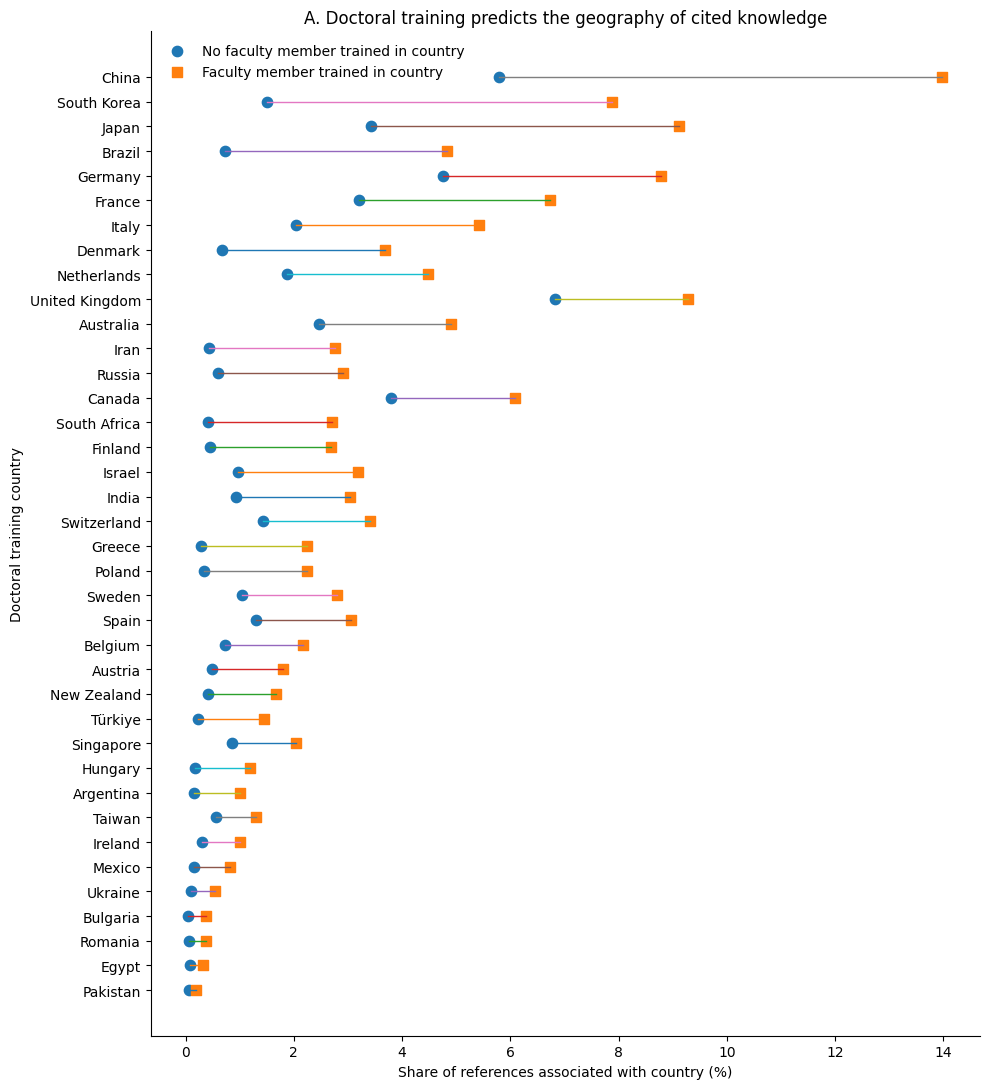

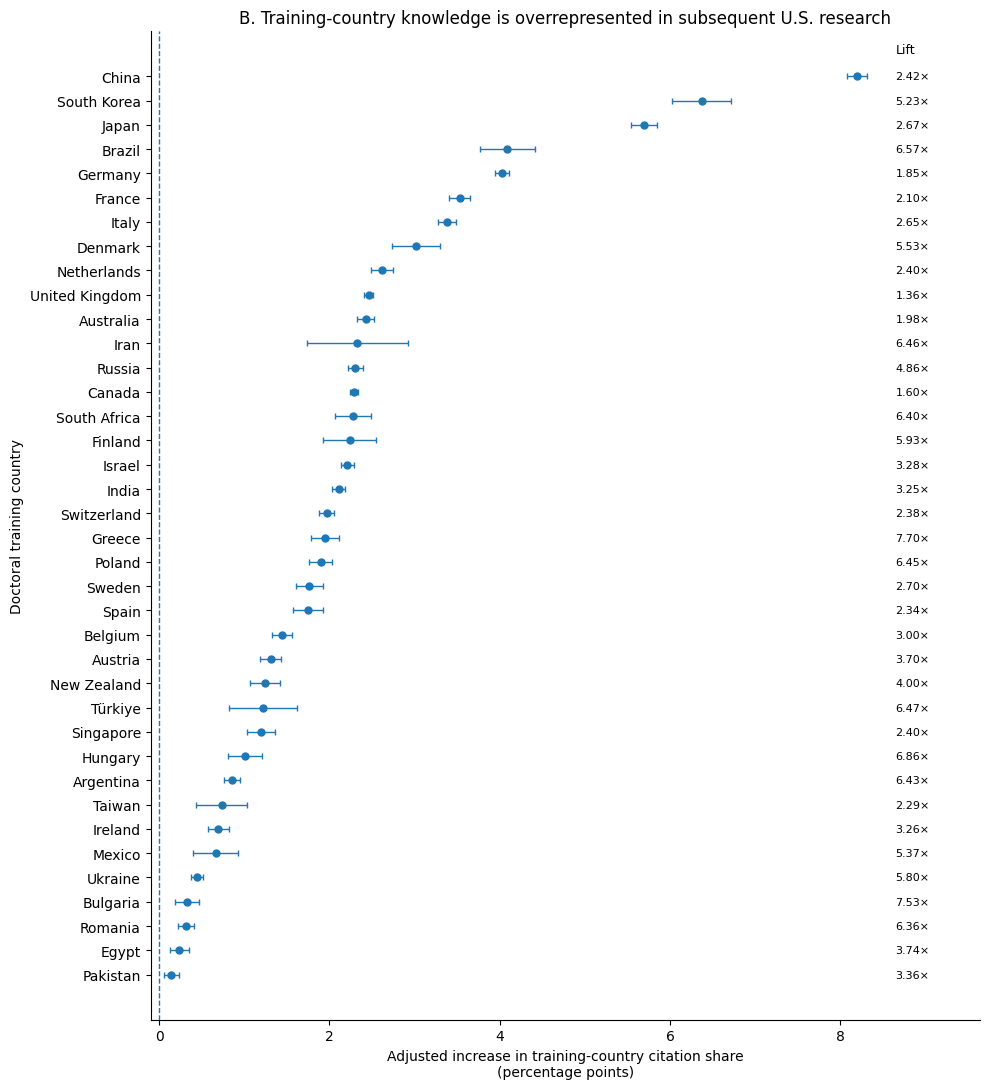

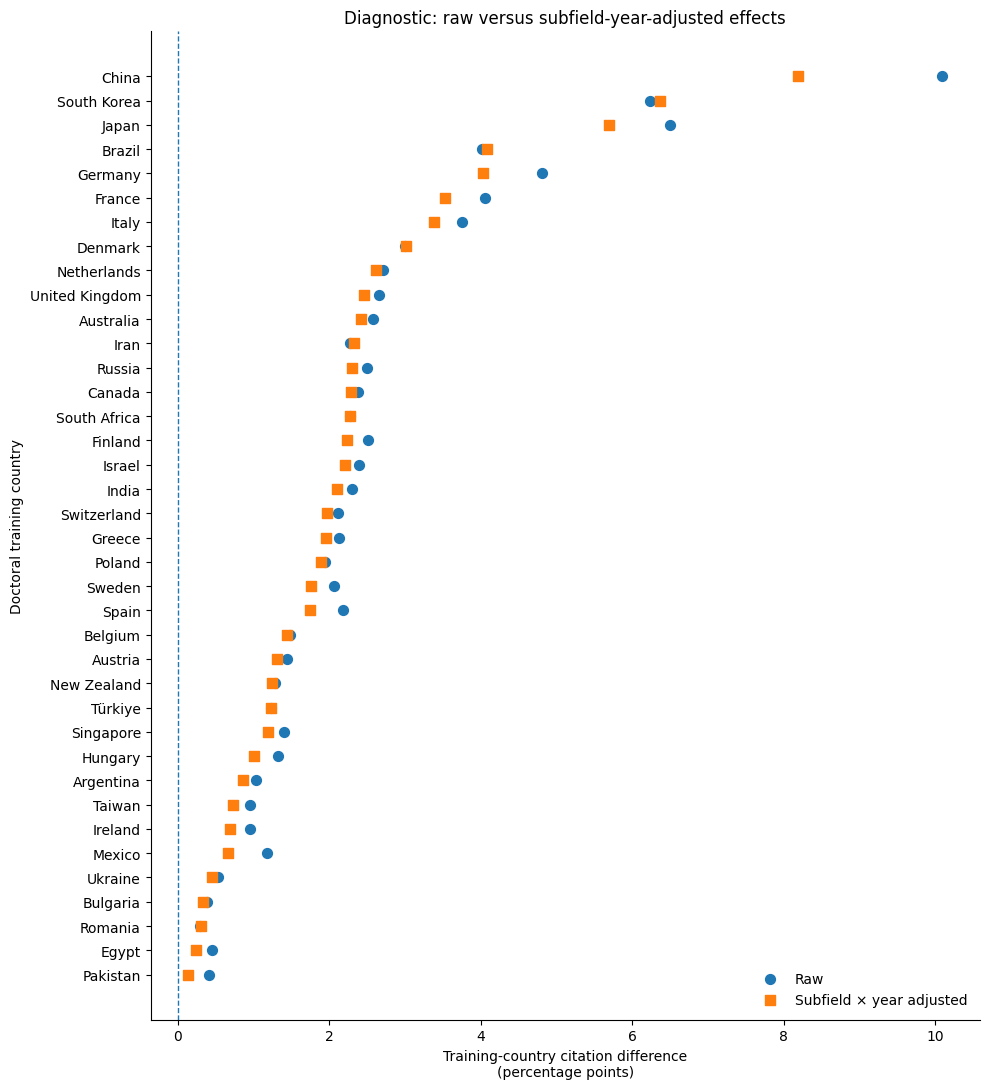


FIGURE 1 MANUSCRIPT SUMMARY

n_countries: 38
positive_effects: 38
ci_above_zero: 38
median_lift: 3.534
median_difference_pp: 1.961
min_lift: 1.360
max_lift: 7.700
largest_absolute_country: China
largest_absolute_difference_pp: 8.197


In [ ]:
# =====================================================================
# FIGURE 1
# DOCTORAL TRAINING AND THE GEOGRAPHY OF KNOWLEDGE USE
# =====================================================================

from google.cloud import bigquery

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# 1. LOAD FIGURE 1 RESULTS
# ---------------------------------------------------------------------

client = bigquery.Client(project="foreign-phd")

query = """
SELECT
  degree_country_rank,
  target_degree_country,
  target_country_code,

  n_faculty,
  n_exposed_raw,
  n_exposed_adjusted,
  n_valid_subfield_year_strata,

  100 * control_mean_adj AS control_share_pct,
  100 * exposed_mean_adj AS exposed_share_pct,

  difference_pp_adj,
  difference_se_pp,

  ci95_low_pp,
  ci95_high_pp,

  lift_adj,
  lift_pct_adj,

  100 * difference_raw AS difference_pp_raw,
  lift_raw

FROM
  `foreign-phd.unitanalysis.broker2_fig1_results`
"""

df = client.query(query).to_dataframe()


# ---------------------------------------------------------------------
# 2. BASIC VALIDATION
# ---------------------------------------------------------------------

print("Countries:", len(df))
print()

print(
    "Countries with positive adjusted difference:",
    (df["difference_pp_adj"] > 0).sum(),
    "of",
    len(df)
)

print(
    "Countries with 95% CI entirely above zero:",
    (df["ci95_low_pp"] > 0).sum(),
    "of",
    len(df)
)

print(
    "Median adjusted lift:",
    round(df["lift_adj"].median(), 3)
)

print(
    "Median adjusted absolute difference:",
    round(df["difference_pp_adj"].median(), 3),
    "percentage points"
)

print(
    "Total exposed papers represented across country analyses:",
    int(df["n_exposed_adjusted"].sum())
)


# ---------------------------------------------------------------------
# 3. DIAGNOSTIC TABLE
# ---------------------------------------------------------------------

diagnostic_cols = [
    "target_degree_country",
    "target_country_code",

    "n_faculty",
    "n_exposed_raw",
    "n_exposed_adjusted",

    "n_valid_subfield_year_strata",

    "control_share_pct",
    "exposed_share_pct",

    "difference_pp_raw",
    "difference_pp_adj",

    "ci95_low_pp",
    "ci95_high_pp",

    "lift_raw",
    "lift_adj",
]

diagnostic = (
    df[diagnostic_cols]
    .sort_values(
        "difference_pp_adj",
        ascending=False
    )
    .copy()
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

print("\nFIGURE 1 COUNTRY RESULTS\n")

print(
    diagnostic
    .round(3)
    .to_string(index=False)
)


# ---------------------------------------------------------------------
# 4. OPTIONAL: BOOTSTRAP STANDARDIZED EFFECTS OVER SUBFIELD-YEAR STRATA
#
# This gives us a second uncertainty estimate based on the aggregate
# stratum table without downloading millions of paper-country rows.
#
# The analytic CI above should remain available for reproducibility.
# The bootstrap can be used as a sensitivity check.
# ---------------------------------------------------------------------

strata_query = """
SELECT
  target_degree_country,
  target_country_code,
  subfield_id,
  publication_year,

  n_exposed,
  n_control,

  exposed_mean,
  control_mean

FROM
  `foreign-phd.unitanalysis.broker2_fig1_strata`
"""

strata = client.query(strata_query).to_dataframe()


def standardized_effect(g):
    """
    Standardize both exposed and control means to the
    exposed-paper subfield-year distribution.
    """

    total_exposed = g["n_exposed"].sum()

    if total_exposed <= 0:
        return np.nan

    w = g["n_exposed"] / total_exposed

    exposed = np.sum(
        w * g["exposed_mean"]
    )

    control = np.sum(
        w * g["control_mean"]
    )

    return 100 * (exposed - control)


def bootstrap_country(
    g,
    n_boot=1000,
    seed=42
):
    """
    Cluster-style bootstrap over subfield-year strata.

    Each row in g is one subfield-year stratum.
    """

    rng = np.random.default_rng(seed)

    g = g.reset_index(drop=True)

    n = len(g)

    if n < 2:
        return pd.Series({
            "boot_low_pp": np.nan,
            "boot_high_pp": np.nan,
            "boot_se_pp": np.nan
        })

    values = np.empty(n_boot)

    for b in range(n_boot):

        idx = rng.integers(
            0,
            n,
            size=n
        )

        sample = g.iloc[idx]

        values[b] = standardized_effect(sample)

    return pd.Series({
        "boot_low_pp": np.nanpercentile(values, 2.5),
        "boot_high_pp": np.nanpercentile(values, 97.5),
        "boot_se_pp": np.nanstd(values, ddof=1)
    })


boot_list = []

for i, (country, g) in enumerate(
    strata.groupby("target_degree_country")
):

    out = bootstrap_country(
        g,
        n_boot=1000,
        seed=42 + i
    )

    out["target_degree_country"] = country

    boot_list.append(out)


boot = pd.DataFrame(boot_list)

df = df.merge(
    boot,
    on="target_degree_country",
    how="left"
)


print("\nANALYTIC VS STRATUM-BOOTSTRAP CI\n")

print(
    df[
        [
            "target_degree_country",
            "difference_pp_adj",
            "ci95_low_pp",
            "ci95_high_pp",
            "boot_low_pp",
            "boot_high_pp"
        ]
    ]
    .sort_values(
        "difference_pp_adj",
        ascending=False
    )
    .round(3)
    .to_string(index=False)
)


# =====================================================================
# 5. FIGURE 1A
#
# ADJUSTED CONTROL VS EXPOSED COUNTRY-KNOWLEDGE SHARES
#
# This panel communicates the substantive magnitude directly.
# =====================================================================

plot_df = (
    df
    .dropna(
        subset=[
            "control_share_pct",
            "exposed_share_pct"
        ]
    )
    .sort_values(
        "difference_pp_adj",
        ascending=True
    )
    .reset_index(drop=True)
)

y = np.arange(len(plot_df))


fig, ax = plt.subplots(
    figsize=(10, 11)
)


# Connecting lines

for i in range(len(plot_df)):

    ax.plot(
        [
            plot_df.loc[i, "control_share_pct"],
            plot_df.loc[i, "exposed_share_pct"]
        ],
        [i, i],
        linewidth=1
    )


# Control points

ax.scatter(
    plot_df["control_share_pct"],
    y,
    marker="o",
    s=55,
    label="No faculty member trained in country"
)


# Exposed points

ax.scatter(
    plot_df["exposed_share_pct"],
    y,
    marker="s",
    s=55,
    label="Faculty member trained in country"
)


ax.set_yticks(y)

ax.set_yticklabels(
    plot_df["target_degree_country"]
)

ax.set_xlabel(
    "Share of references associated with country (%)"
)

ax.set_ylabel(
    "Doctoral training country"
)

ax.set_title(
    "A. Doctoral training predicts the geography of cited knowledge"
)

ax.legend(
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# =====================================================================
# 6. FIGURE 1B
#
# ADJUSTED ABSOLUTE DIFFERENCE WITH 95% CI
#
# Main estimand:
#
# percentage-point change in target-country citation share
#
# associated with presence of faculty trained in that country,
# standardized by OpenAlex subfield x year.
# =====================================================================

plot_df = (
    df
    .dropna(
        subset=[
            "difference_pp_adj",
            "ci95_low_pp",
            "ci95_high_pp"
        ]
    )
    .sort_values(
        "difference_pp_adj",
        ascending=True
    )
    .reset_index(drop=True)
)

y = np.arange(len(plot_df))


lower_error = (
    plot_df["difference_pp_adj"]
    - plot_df["ci95_low_pp"]
)

upper_error = (
    plot_df["ci95_high_pp"]
    - plot_df["difference_pp_adj"]
)


fig, ax = plt.subplots(
    figsize=(10, 11)
)


ax.errorbar(
    plot_df["difference_pp_adj"],
    y,

    xerr=np.vstack(
        [
            lower_error,
            upper_error
        ]
    ),

    fmt="o",
    markersize=5,
    capsize=2,
    linewidth=1
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(y)

ax.set_yticklabels(
    plot_df["target_degree_country"]
)


ax.set_xlabel(
    "Adjusted increase in training-country citation share\n"
    "(percentage points)"
)

ax.set_ylabel(
    "Doctoral training country"
)

ax.set_title(
    "B. Training-country knowledge is overrepresented in subsequent U.S. research"
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ---------------------------------------------------------------------
# Annotate relative lift on right side
# ---------------------------------------------------------------------

x_range = (
    plot_df["ci95_high_pp"].max()
    - plot_df["ci95_low_pp"].min()
)

annotation_x = (
    plot_df["ci95_high_pp"].max()
    + 0.04 * x_range
)


for i, row in plot_df.iterrows():

    ax.text(
        annotation_x,
        i,
        f"{row['lift_adj']:.2f}×",
        va="center",
        fontsize=8
    )


ax.text(
    annotation_x,
    len(plot_df) - 0.15,
    "Lift",
    va="bottom",
    fontsize=9
)


ax.set_xlim(
    left=min(
        -0.1,
        plot_df["ci95_low_pp"].min()
    ),

    right=(
        annotation_x
        + 0.12 * x_range
    )
)


plt.tight_layout()
plt.show()


# =====================================================================
# 7. RAW VS ADJUSTED DIAGNOSTIC
#
# Not necessarily a main-text panel.
# Important to inspect before finalizing Fig. 1.
# =====================================================================

plot_df = (
    df
    .dropna(
        subset=[
            "difference_pp_raw",
            "difference_pp_adj"
        ]
    )
    .sort_values(
        "difference_pp_adj",
        ascending=True
    )
    .reset_index(drop=True)
)

y = np.arange(len(plot_df))


fig, ax = plt.subplots(
    figsize=(10, 11)
)


ax.scatter(
    plot_df["difference_pp_raw"],
    y,
    marker="o",
    s=50,
    label="Raw"
)


ax.scatter(
    plot_df["difference_pp_adj"],
    y,
    marker="s",
    s=50,
    label="Subfield × year adjusted"
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(y)

ax.set_yticklabels(
    plot_df["target_degree_country"]
)


ax.set_xlabel(
    "Training-country citation difference\n"
    "(percentage points)"
)

ax.set_ylabel(
    "Doctoral training country"
)

ax.set_title(
    "Diagnostic: raw versus subfield-year-adjusted effects"
)

ax.legend(
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# =====================================================================
# 8. SUMMARY STATISTICS FOR MANUSCRIPT DRAFTING
# =====================================================================

summary = {

    "n_countries":
        len(df),

    "positive_effects":
        int(
            (df["difference_pp_adj"] > 0).sum()
        ),

    "ci_above_zero":
        int(
            (df["ci95_low_pp"] > 0).sum()
        ),

    "median_lift":
        df["lift_adj"].median(),

    "median_difference_pp":
        df["difference_pp_adj"].median(),

    "min_lift":
        df["lift_adj"].min(),

    "max_lift":
        df["lift_adj"].max(),

    "largest_absolute_country":
        df.loc[
            df["difference_pp_adj"].idxmax(),
            "target_degree_country"
        ],

    "largest_absolute_difference_pp":
        df["difference_pp_adj"].max()
}


print("\nFIGURE 1 MANUSCRIPT SUMMARY\n")

for k, v in summary.items():

    if isinstance(v, float):
        print(
            f"{k}: {v:.3f}"
        )

    else:
        print(
            f"{k}: {v}"
        )

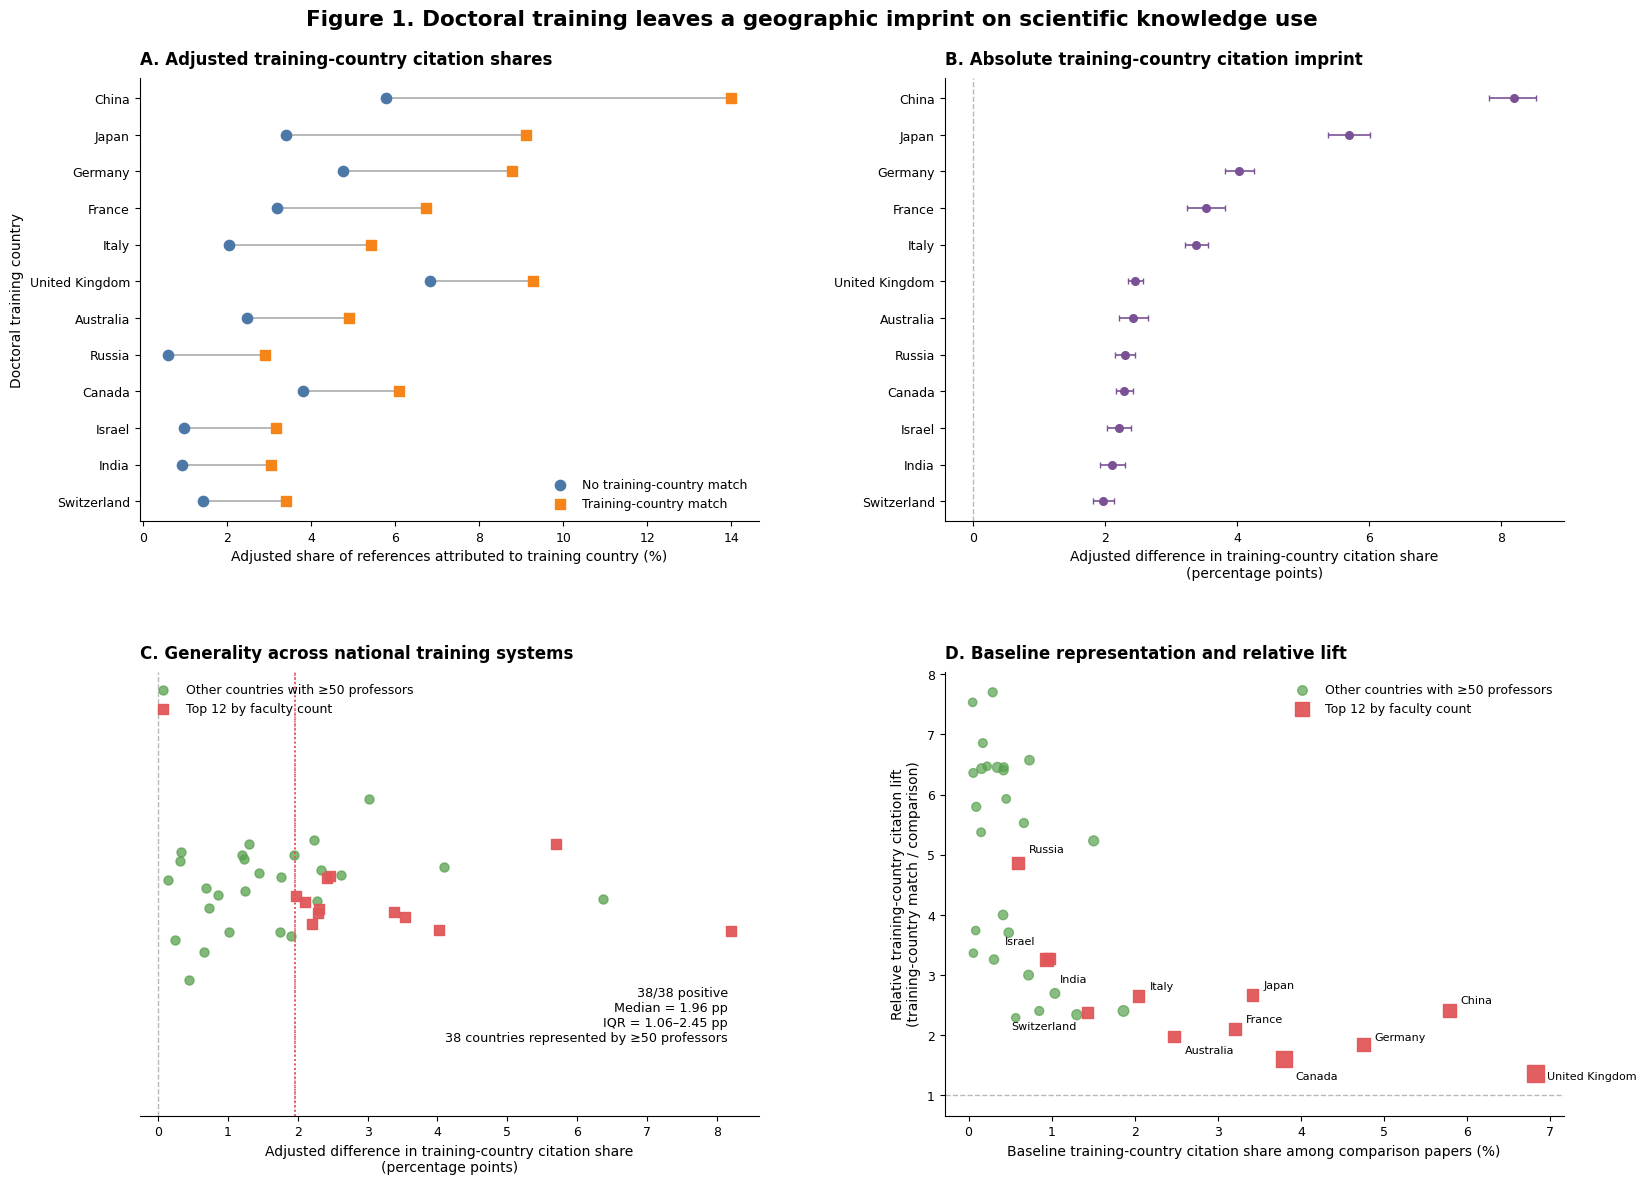

In [ ]:
# =====================================================================
# FIGURE 1 — REVISED FOUR-PANEL DESIGN
#
# A. Top 12:
#    adjusted comparison vs training-country-match shares
#
# B. Top 12:
#    adjusted absolute difference + bootstrap 95% CI
#
# C. 38 countries with >=50 professors:
#    distribution of adjusted effects
#
# D. Same 38 countries:
#    baseline representation vs relative lift
#
# COLOR LOGIC
# -----------
# Panel A: one palette
# Panel B: separate palette
# Panels C/D: third shared palette
#
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =====================================================================
# 1. PREPARE DATA
# =====================================================================

fig1_all = df.copy()

required_cols = [
    "target_degree_country",
    "target_country_code",
    "n_faculty",
    "control_share_pct",
    "exposed_share_pct",
    "difference_pp_adj",
    "lift_adj",
    "boot_low_pp",
    "boot_high_pp"
]

missing = [
    c for c in required_cols
    if c not in fig1_all.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )


# =====================================================================
# 2. DEFINE THE 38-COUNTRY ANALYTIC SET
#
# Explicit inclusion rule:
# doctoral-training countries represented by >=50 professors.
# =====================================================================

country38_codes = [
    'GB','CA','DE','CN','IN','RU','FR','AU','IT','JP',
    'IL','CH','NL','ES','PL','KR','SE','AR','BE','AT',
    'BR','NZ','IE','ZA','DK','GR','UA','SG','RO','HU',
    'MX','IR','FI','TR','BG','EG','PK','TW'
]

country38 = (
    fig1_all[
        fig1_all["target_country_code"].isin(country38_codes)
    ]
    .copy()
)

if len(country38) != 38:
    print(
        f"WARNING: expected 38 countries but found {len(country38)}."
    )


# =====================================================================
# 3. DEFINE TOP 12
#
# Mechanical rule:
# largest 12 countries by number of professors.
# =====================================================================

top12_selection = (
    country38
    .sort_values(
        ["n_faculty", "target_degree_country"],
        ascending=[False, True]
    )
    .head(12)
    .copy()
)

top12_names = set(
    top12_selection["target_degree_country"]
)

# Order top 12 by absolute adjusted effect for Panels A/B
top12 = (
    top12_selection
    .sort_values(
        "difference_pp_adj",
        ascending=True
    )
    .reset_index(drop=True)
)


# =====================================================================
# 4. PREPARE 38-COUNTRY DATA
# =====================================================================

country38 = (
    country38
    .sort_values(
        "difference_pp_adj",
        ascending=True
    )
    .reset_index(drop=True)
)

country38["is_top12"] = (
    country38["target_degree_country"]
    .isin(top12_names)
)


# =====================================================================
# 5. SUMMARY STATISTICS
# =====================================================================

n_countries = len(country38)

n_positive = int(
    (country38["difference_pp_adj"] > 0).sum()
)

median_effect = float(
    country38["difference_pp_adj"].median()
)

q25_effect = float(
    country38["difference_pp_adj"].quantile(0.25)
)

q75_effect = float(
    country38["difference_pp_adj"].quantile(0.75)
)


# =====================================================================
# 6. COLOR SYSTEM
#
# A = one palette
# B = second palette
# C/D = third palette
# =====================================================================

# Panel A
A_control = "#4C78A8"
A_exposed = "#F58518"
A_connector = "#B8B8B8"

# Panel B
B_effect = "#7A5195"
B_reference = "#B8B8B8"

# Panels C/D
CD_other = "#59A14F"
CD_top12 = "#E15759"
CD_reference = "#B8B8B8"


# =====================================================================
# 7. FIGURE LAYOUT
# =====================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12.5)
)

axA = axes[0, 0]
axB = axes[0, 1]
axC = axes[1, 0]
axD = axes[1, 1]


plt.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.91,
    bottom=0.08,
    wspace=0.30,
    hspace=0.34
)


# =====================================================================
# PANEL A
# ADJUSTED TRAINING-COUNTRY CITATION SHARES
# TOP 12
# =====================================================================

yA = np.arange(len(top12))


# ---------------------------------------------------------
# SINGLE neutral connector color for every country
# ---------------------------------------------------------

for i, row in top12.iterrows():

    axA.plot(
        [
            row["control_share_pct"],
            row["exposed_share_pct"]
        ],
        [i, i],
        color=A_connector,
        linewidth=1.4,
        zorder=1
    )


# ---------------------------------------------------------
# No training-country match
# ---------------------------------------------------------

axA.scatter(
    top12["control_share_pct"],
    yA,
    marker="o",
    s=55,
    color=A_control,
    label="No training-country match",
    zorder=3
)


# ---------------------------------------------------------
# Training-country match
# ---------------------------------------------------------

axA.scatter(
    top12["exposed_share_pct"],
    yA,
    marker="s",
    s=55,
    color=A_exposed,
    label="Training-country match",
    zorder=3
)


axA.set_yticks(yA)

axA.set_yticklabels(
    top12["target_degree_country"]
)

axA.set_xlabel(
    "Adjusted share of references attributed to training country (%)"
)

axA.set_ylabel(
    "Doctoral training country"
)

axA.set_title(
    "A. Adjusted training-country citation shares",
    loc="left",
    fontweight="bold",
    pad=10
)

axA.legend(
    frameon=False,
    loc="lower right",
    fontsize=9
)

axA.spines["top"].set_visible(False)
axA.spines["right"].set_visible(False)


# =====================================================================
# PANEL B
# ABSOLUTE TRAINING-COUNTRY CITATION IMPRINT
# TOP 12
# =====================================================================

yB = np.arange(len(top12))

lower_err = (
    top12["difference_pp_adj"]
    - top12["boot_low_pp"]
)

upper_err = (
    top12["boot_high_pp"]
    - top12["difference_pp_adj"]
)


axB.errorbar(
    top12["difference_pp_adj"],
    yB,
    xerr=np.vstack([
        lower_err,
        upper_err
    ]),
    fmt="o",
    color=B_effect,
    ecolor=B_effect,
    markersize=5.5,
    capsize=2.5,
    linewidth=1.2
)


axB.axvline(
    0,
    color=B_reference,
    linestyle="--",
    linewidth=1
)


axB.set_yticks(yB)

axB.set_yticklabels(
    top12["target_degree_country"]
)

axB.set_xlabel(
    "Adjusted difference in training-country citation share\n"
    "(percentage points)"
)

axB.set_ylabel("")

axB.set_title(
    "B. Absolute training-country citation imprint",
    loc="left",
    fontweight="bold",
    pad=10
)

axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)


# =====================================================================
# PANEL C
# GENERALITY ACROSS 38 COUNTRIES WITH >=50 PROFESSORS
# =====================================================================

rng = np.random.default_rng(42)

jitter = rng.normal(
    loc=0,
    scale=0.05,
    size=len(country38)
)

jitter = np.clip(
    jitter,
    -0.11,
    0.11
)


other38 = country38[
    ~country38["is_top12"]
].copy()

other_mask = (
    ~country38["is_top12"]
).to_numpy()

other_jitter = jitter[
    other_mask
]


highlight38 = country38[
    country38["is_top12"]
].copy()

highlight_mask = (
    country38["is_top12"]
).to_numpy()

highlight_jitter = jitter[
    highlight_mask
]


# ---------------------------------------------------------
# Other countries
# ---------------------------------------------------------

axC.scatter(
    other38["difference_pp_adj"],
    other_jitter,
    s=42,
    marker="o",
    color=CD_other,
    alpha=0.75,
    label="Other countries with ≥50 professors"
)


# ---------------------------------------------------------
# Top 12
# ---------------------------------------------------------

axC.scatter(
    highlight38["difference_pp_adj"],
    highlight_jitter,
    s=62,
    marker="s",
    color=CD_top12,
    alpha=0.95,
    label="Top 12 by faculty count"
)


# ---------------------------------------------------------
# Zero + median
# ---------------------------------------------------------

axC.axvline(
    0,
    color=CD_reference,
    linestyle="--",
    linewidth=1
)

axC.axvline(
    median_effect,
    color=CD_top12,
    linestyle=":",
    linewidth=1.25
)


axC.set_xlabel(
    "Adjusted difference in training-country citation share\n"
    "(percentage points)"
)

axC.set_ylabel("")

axC.set_yticks([])

axC.set_ylim(
    -0.25,
    0.25
)

axC.set_title(
    "C. Generality across national training systems",
    loc="left",
    fontweight="bold",
    pad=10
)

axC.spines["top"].set_visible(False)
axC.spines["right"].set_visible(False)
axC.spines["left"].set_visible(False)

axC.tick_params(
    axis="y",
    length=0
)


# ---------------------------------------------------------
# Summary annotation
# ---------------------------------------------------------

summary_text = (
    f"{n_positive}/{n_countries} positive\n"
    f"Median = {median_effect:.2f} pp\n"
    f"IQR = {q25_effect:.2f}–{q75_effect:.2f} pp\n"
    f"38 countries represented by ≥50 professors"
)

axC.text(
    0.95,
    0.16,
    summary_text,
    transform=axC.transAxes,
    ha="right",
    va="bottom",
    fontsize=9.2
)
axC.axvline(
    median_effect,
    color=CD_top12,
    linestyle=":",
    linewidth=1.15
)

# ---------------------------------------------------------
# Median label
# ---------------------------------------------------------


axC.legend(
    frameon=False,
    loc="upper left",
    fontsize=9
)


# =====================================================================
# PANEL D
# BASELINE REPRESENTATION VS RELATIVE LIFT
# SAME 38 COUNTRIES
# =====================================================================


# ---------------------------------------------------------
# Point size = faculty count
# sqrt scaling
# ---------------------------------------------------------

sqrt_n = np.sqrt(
    country38["n_faculty"]
)

size_min = 35
size_max = 140

if sqrt_n.max() > sqrt_n.min():

    point_sizes = (
        size_min
        +
        (
            (sqrt_n - sqrt_n.min())
            /
            (sqrt_n.max() - sqrt_n.min())
        )
        * (size_max - size_min)
    )

else:

    point_sizes = np.repeat(
        70,
        len(country38)
    )


country38 = country38.copy()

country38["point_size"] = point_sizes


other = country38[
    ~country38["is_top12"]
]

highlight = country38[
    country38["is_top12"]
]


# ---------------------------------------------------------
# Other 26 countries
# ---------------------------------------------------------

axD.scatter(
    other["control_share_pct"],
    other["lift_adj"],
    s=other["point_size"],
    marker="o",
    color=CD_other,
    alpha=0.70,
    label="Other countries with ≥50 professors"
)


# ---------------------------------------------------------
# Top 12
# ---------------------------------------------------------

axD.scatter(
    highlight["control_share_pct"],
    highlight["lift_adj"],
    s=highlight["point_size"],
    marker="s",
    color=CD_top12,
    alpha=0.95,
    label="Top 12 by faculty count"
)


axD.axhline(
    1,
    color=CD_reference,
    linestyle="--",
    linewidth=1
)


axD.set_xlabel(
    "Baseline training-country citation share among comparison papers (%)"
)

axD.set_ylabel(
    "Relative training-country citation lift\n"
    "(training-country match / comparison)"
)

axD.set_title(
    "D. Baseline representation and relative lift",
    loc="left",
    fontweight="bold",
    pad=10
)

axD.spines["top"].set_visible(False)
axD.spines["right"].set_visible(False)


# =====================================================================
# LABEL ALL TOP 12 COUNTRIES
# =====================================================================
manual_label_settings = {

    "United Kingdom": {
        "offset": (8, -2),
        "ha": "left"
    },

    "Canada": {
        "offset": (8, -12),
        "ha": "left"
    },

    "Germany": {
        "offset": (8, 5),
        "ha": "left"
    },

    "China": {
        "offset": (8, 7),
        "ha": "left"
    },

    "India": {
        "offset": (10, -14),
        "ha": "left"
    },

    "Russia": {
        "offset": (8, 10),
        "ha": "left"
    },

    "France": {
        "offset": (8, 7),
        "ha": "left"
    },

    "Australia": {
        "offset": (8, -10),
        "ha": "left"
    },

    "Italy": {
        "offset": (8, 7),
        "ha": "left"
    },

    "Japan": {
        "offset": (8, 7),
        "ha": "left"
    },

    "Israel": {
        "offset": (-10, 12),
        "ha": "right"
    },

    "Switzerland": {
        "offset": (-8, -10),
        "ha": "right"
    }
}


for _, row in highlight.iterrows():

    country = row["target_degree_country"]

    settings = manual_label_settings.get(
        country,
        {
            "offset": (7, 6),
            "ha": "left"
        }
    )

    axD.annotate(
        country,
        (
            row["control_share_pct"],
            row["lift_adj"]
        ),
        xytext=settings["offset"],
        textcoords="offset points",
        fontsize=8,
        ha=settings["ha"],
        va="center"
    )


axD.legend(
    frameon=False,
    loc="upper right",
    fontsize=9
)


# =====================================================================
# 8. SHARED FORMATTING
# =====================================================================

for ax in [
    axA,
    axB,
    axC,
    axD
]:

    ax.tick_params(
        axis="both",
        labelsize=9
    )


fig.suptitle(
    "Figure 1. Doctoral training leaves a geographic imprint on scientific knowledge use",
    fontsize=15.5,
    fontweight="bold",
    y=0.965
)


plt.show()


# =====================================================================
# OPTIONAL EXPORT
# =====================================================================

# fig.savefig(
#     "figure1_geographic_knowledge_imprint.pdf",
#     bbox_inches="tight"
# )

# fig.savefig(
#     "figure1_geographic_knowledge_imprint.png",
#     dpi=400,
#     bbox_inches="tight"
# )

FIGURE 2 DIAGNOSTICS
--------------------
Country pairs: 1444
Matching pairs: 38
Nonmatching pairs: 1406
Positive specificity: 38 of 38
Median specificity: 1.986 pp
Median matching effect: 1.961 pp
Median nonmatching effect: -0.007 pp


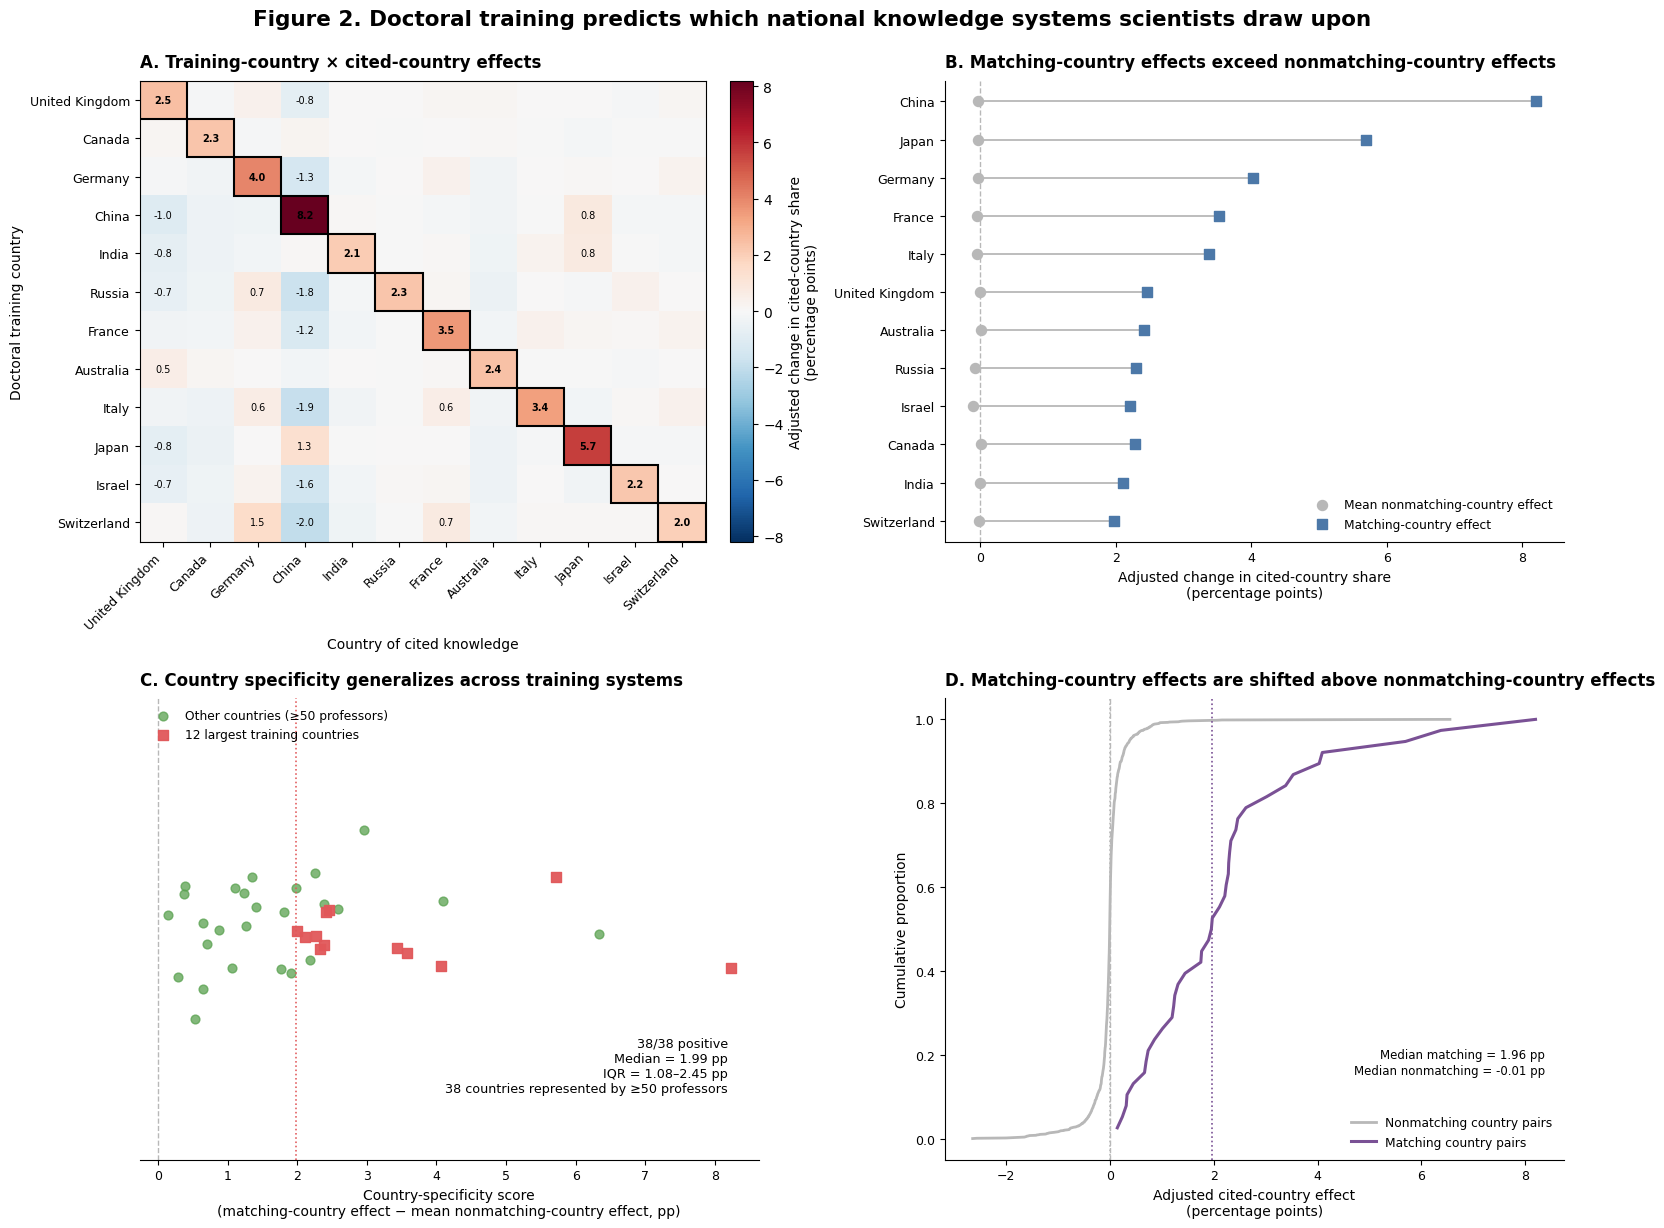

In [ ]:
# =====================================================================
# FIGURE 2
# COUNTRY SPECIFICITY OF THE TRAINING-COUNTRY KNOWLEDGE IMPRINT
#
# A. 12 x 12 training-country x cited-country heatmap
# B. Top 12 matching-country vs mean nonmatching-country effect
# C. Specificity across 38 countries with >=50 professors
# D. Distribution of matching vs nonmatching country-pair effects
# =====================================================================

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =====================================================================
# 1. CONNECT
# =====================================================================

client = bigquery.Client(project="foreign-phd")


# =====================================================================
# 2. LOAD DATA
# =====================================================================

heat = client.query("""
SELECT *
FROM `foreign-phd.unitanalysis.broker2_fig2_heatmap12`
""").to_dataframe()

spec = client.query("""
SELECT *
FROM `foreign-phd.unitanalysis.broker2_fig2_specificity`
""").to_dataframe()

pairs = client.query("""
SELECT *
FROM `foreign-phd.unitanalysis.broker2_fig2_pair_results`
""").to_dataframe()


# =====================================================================
# 3. DEFINE TOP 12
#
# Mechanical rule:
# 12 largest training countries by number of professors.
# =====================================================================

top12 = (
    spec
    .sort_values(
        ["training_country_n_faculty", "training_country"],
        ascending=[False, True]
    )
    .head(12)
    .copy()
)

top12_codes = list(top12["training_country_code"])
top12_names = list(top12["training_country"])

code_to_name = dict(
    zip(
        top12["training_country_code"],
        top12["training_country"]
    )
)


# =====================================================================
# 4. PANEL A DATA
# =====================================================================

heat12 = heat[
    heat["training_country_code"].isin(top12_codes)
    &
    heat["cited_country_code"].isin(top12_codes)
].copy()

matrix = (
    heat12
    .pivot(
        index="training_country_code",
        columns="cited_country_code",
        values="difference_pp_adj"
    )
    .reindex(
        index=top12_codes,
        columns=top12_codes
    )
)


# =====================================================================
# 5. PANEL B DATA
#
# Order by specificity so matching/nonmatching contrast is easy to read.
# =====================================================================

spec12 = (
    spec[
        spec["training_country_code"].isin(top12_codes)
    ]
    .sort_values(
        "specificity_mean_pp",
        ascending=True
    )
    .reset_index(drop=True)
)


# =====================================================================
# 6. PANEL C DATA
# =====================================================================

spec38 = (
    spec
    .sort_values("specificity_mean_pp")
    .reset_index(drop=True)
    .copy()
)

spec38["is_top12"] = (
    spec38["training_country_code"]
    .isin(top12_codes)
)

n38 = len(spec38)

n_positive_specificity = int(
    (spec38["specificity_mean_pp"] > 0).sum()
)

median_specificity = float(
    spec38["specificity_mean_pp"].median()
)

q25_specificity = float(
    spec38["specificity_mean_pp"].quantile(0.25)
)

q75_specificity = float(
    spec38["specificity_mean_pp"].quantile(0.75)
)


# =====================================================================
# 7. PANEL D DATA
# =====================================================================

diag = (
    pairs[
        pairs["is_diagonal"] == 1
    ]["difference_pp_adj"]
    .dropna()
)

offdiag = (
    pairs[
        pairs["is_diagonal"] == 0
    ]["difference_pp_adj"]
    .dropna()
)

diag_med = float(np.median(diag))
off_med = float(np.median(offdiag))


print("FIGURE 2 DIAGNOSTICS")
print("--------------------")
print("Country pairs:", len(pairs))
print("Matching pairs:", len(diag))
print("Nonmatching pairs:", len(offdiag))
print(
    "Positive specificity:",
    n_positive_specificity,
    "of",
    n38
)
print(
    "Median specificity:",
    round(median_specificity, 3),
    "pp"
)
print(
    "Median matching effect:",
    round(diag_med, 3),
    "pp"
)
print(
    "Median nonmatching effect:",
    round(off_med, 3),
    "pp"
)


# =====================================================================
# 8. COLOR SYSTEM
# =====================================================================

# Panel A
A_cmap = "RdBu_r"

# Panel B
B_matching = "#4C78A8"
B_nonmatching = "#B8B8B8"
B_connector = "#B8B8B8"

# Panel C
C_other = "#59A14F"
C_top12 = "#E15759"
REFERENCE = "#B8B8B8"

# Panel D
D_matching = "#7A5195"
D_nonmatching = "#B8B8B8"


# =====================================================================
# 9. FIGURE LAYOUT
# =====================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 13)
)

axA = axes[0, 0]
axB = axes[0, 1]
axC = axes[1, 0]
axD = axes[1, 1]

plt.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.91,
    bottom=0.08,
    wspace=0.30,
    hspace=0.34
)


# =====================================================================
# PANEL A
# TRAINING-COUNTRY x CITED-COUNTRY HEATMAP
# =====================================================================

max_abs = np.nanmax(
    np.abs(matrix.to_numpy())
)

im = axA.imshow(
    matrix.to_numpy(),
    cmap=A_cmap,
    vmin=-max_abs,
    vmax=max_abs,
    aspect="auto"
)

axA.set_xticks(
    np.arange(len(top12_codes))
)

axA.set_yticks(
    np.arange(len(top12_codes))
)

axA.set_xticklabels(
    [code_to_name[c] for c in top12_codes],
    rotation=45,
    ha="right"
)

axA.set_yticklabels(
    [code_to_name[c] for c in top12_codes]
)

axA.set_xlabel(
    "Country of cited knowledge"
)

axA.set_ylabel(
    "Doctoral training country"
)

axA.set_title(
    "A. Training-country × cited-country effects",
    loc="left",
    fontweight="bold",
    pad=10
)


# ---------------------------------------------------------
# Annotate:
# - all diagonal cells
# - off-diagonal cells only if |effect| >= 0.5 pp
# ---------------------------------------------------------

for i in range(len(top12_codes)):

    for j in range(len(top12_codes)):

        value = matrix.iloc[i, j]

        if pd.isna(value):
            continue

        is_diag = (i == j)

        if is_diag or abs(value) >= 0.5:

            axA.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=7,
                fontweight="bold" if is_diag else "normal"
            )


# ---------------------------------------------------------
# Outline diagonal cells
# ---------------------------------------------------------

for i in range(len(top12_codes)):

    rect = plt.Rectangle(
        (i - 0.5, i - 0.5),
        1,
        1,
        fill=False,
        linewidth=1.5
    )

    axA.add_patch(rect)


cbar = fig.colorbar(
    im,
    ax=axA,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Adjusted change in cited-country share\n"
    "(percentage points)"
)


# =====================================================================
# PANEL B
# MATCHING VS MEAN NONMATCHING EFFECT
# =====================================================================

yB = np.arange(len(spec12))


# ---------------------------------------------------------
# Neutral connectors
# ---------------------------------------------------------

for i, row in spec12.iterrows():

    axB.plot(
        [
            row["mean_wrong_country_effect_pp"],
            row["own_country_effect_pp"]
        ],
        [i, i],
        color=B_connector,
        linewidth=1.3,
        zorder=1
    )


# ---------------------------------------------------------
# Mean nonmatching effect
# ---------------------------------------------------------

axB.scatter(
    spec12["mean_wrong_country_effect_pp"],
    yB,
    s=52,
    marker="o",
    color=B_nonmatching,
    label="Mean nonmatching-country effect",
    zorder=3
)


# ---------------------------------------------------------
# Matching-country effect
# ---------------------------------------------------------

axB.scatter(
    spec12["own_country_effect_pp"],
    yB,
    s=58,
    marker="s",
    color=B_matching,
    label="Matching-country effect",
    zorder=3
)


axB.axvline(
    0,
    linestyle="--",
    linewidth=1,
    color=REFERENCE
)

axB.set_yticks(yB)

axB.set_yticklabels(
    spec12["training_country"]
)

axB.set_xlabel(
    "Adjusted change in cited-country share\n"
    "(percentage points)"
)

axB.set_ylabel("")

axB.set_title(
    "B. Matching-country effects exceed nonmatching-country effects",
    loc="left",
    fontweight="bold",
    pad=10
)

axB.legend(
    frameon=False,
    loc="lower right",
    fontsize=8.8
)

axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)


# =====================================================================
# PANEL C
# COUNTRY SPECIFICITY ACROSS 38 TRAINING SYSTEMS
# =====================================================================

rng = np.random.default_rng(42)

jitter = rng.normal(
    loc=0,
    scale=0.05,
    size=len(spec38)
)

jitter = np.clip(
    jitter,
    -0.11,
    0.11
)


other = spec38[
    ~spec38["is_top12"]
].copy()

highlight = spec38[
    spec38["is_top12"]
].copy()

other_mask = (
    ~spec38["is_top12"]
).to_numpy()

highlight_mask = (
    spec38["is_top12"]
).to_numpy()


axC.scatter(
    other["specificity_mean_pp"],
    jitter[other_mask],
    s=40,
    marker="o",
    color=C_other,
    alpha=0.75,
    label="Other countries (≥50 professors)"
)

axC.scatter(
    highlight["specificity_mean_pp"],
    jitter[highlight_mask],
    s=62,
    marker="s",
    color=C_top12,
    alpha=0.95,
    label="12 largest training countries"
)


axC.axvline(
    0,
    linestyle="--",
    linewidth=1,
    color=REFERENCE
)

axC.axvline(
    median_specificity,
    linestyle=":",
    linewidth=1.15,
    color=C_top12
)


axC.set_xlabel(
    "Country-specificity score\n"
    "(matching-country effect − mean nonmatching-country effect, pp)"
)

axC.set_yticks([])
axC.set_ylabel("")

axC.set_ylim(
    -0.25,
    0.25
)

axC.set_title(
    "C. Country specificity generalizes across training systems",
    loc="left",
    fontweight="bold",
    pad=10
)

axC.spines["top"].set_visible(False)
axC.spines["right"].set_visible(False)
axC.spines["left"].set_visible(False)

axC.tick_params(
    axis="y",
    length=0
)


summary_text = (
    f"{n_positive_specificity}/{n38} positive\n"
    f"Median = {median_specificity:.2f} pp\n"
    f"IQR = {q25_specificity:.2f}–{q75_specificity:.2f} pp\n"
    f"38 countries represented by ≥50 professors"
)

axC.text(
    0.95,
    0.14,
    summary_text,
    transform=axC.transAxes,
    ha="right",
    va="bottom",
    fontsize=9.2
)


axC.legend(
    frameon=False,
    loc="upper left",
    fontsize=8.8
)


# =====================================================================
# PANEL D
# MATCHING VS NONMATCHING EFFECT DISTRIBUTIONS
# =====================================================================

def ecdf(values):

    values = np.sort(
        np.asarray(values)
    )

    y = np.arange(
        1,
        len(values) + 1
    ) / len(values)

    return values, y


x_diag, y_diag = ecdf(diag)
x_off, y_off = ecdf(offdiag)


axD.plot(
    x_off,
    y_off,
    color=D_nonmatching,
    linewidth=2,
    label="Nonmatching country pairs"
)

axD.plot(
    x_diag,
    y_diag,
    color=D_matching,
    linewidth=2.2,
    label="Matching country pairs"
)


axD.axvline(
    0,
    linestyle="--",
    linewidth=1,
    color=REFERENCE
)


# median lines
axD.axvline(
    off_med,
    linestyle=":",
    linewidth=1.2,
    color=D_nonmatching
)

axD.axvline(
    diag_med,
    linestyle=":",
    linewidth=1.2,
    color=D_matching
)


axD.set_xlabel(
    "Adjusted cited-country effect\n"
    "(percentage points)"
)

axD.set_ylabel(
    "Cumulative proportion"
)

axD.set_title(
    "D. Matching-country effects are shifted above nonmatching-country effects",
    loc="left",
    fontweight="bold",
    pad=10
)

axD.legend(
    frameon=False,
    loc="lower right",
    fontsize=8.8
)

axD.spines["top"].set_visible(False)
axD.spines["right"].set_visible(False)


# ---------------------------------------------------------
# Median summary
# ---------------------------------------------------------

axD.text(
    0.97,
    0.18,
    (
        f"Median matching = {diag_med:.2f} pp\n"
        f"Median nonmatching = {off_med:.2f} pp"
    ),
    transform=axD.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.5
)


# =====================================================================
# 10. SHARED FORMATTING
# =====================================================================

for ax in [
    axA,
    axB,
    axC,
    axD
]:

    ax.tick_params(
        axis="both",
        labelsize=9
    )


fig.suptitle(
    "Figure 2. Doctoral training predicts which national knowledge systems scientists draw upon",
    fontsize=15.5,
    fontweight="bold",
    y=0.965
)


plt.show()


# =====================================================================
# OPTIONAL EXPORT
# =====================================================================

# fig.savefig(
#     "figure2_country_specificity.pdf",
#     bbox_inches="tight"
# )

# fig.savefig(
#     "figure2_country_specificity.png",
#     dpi=400,
#     bbox_inches="tight"
# )

FIGURE 3 SPECIFICATION SUMMARY
------------------------------
 spec_order                                                    spec_label  n_countries  n_positive  median_effect_pp  q25_effect_pp  q75_effect_pp  total_exposed_adjusted
          1                                                      Baseline           38          38             1.951          1.012          2.460                  521926
          2                           No active training-country coauthor           38          38             1.032          0.492          1.474                  425797
          3                   No active coauthor + no team self-citations           38          37             0.716          0.356          1.145                  425653
          4                                         U.S.-only citing team           38          37             0.965          0.328          1.566                  204851
          5                       U.S.-only team + no team self-citations          

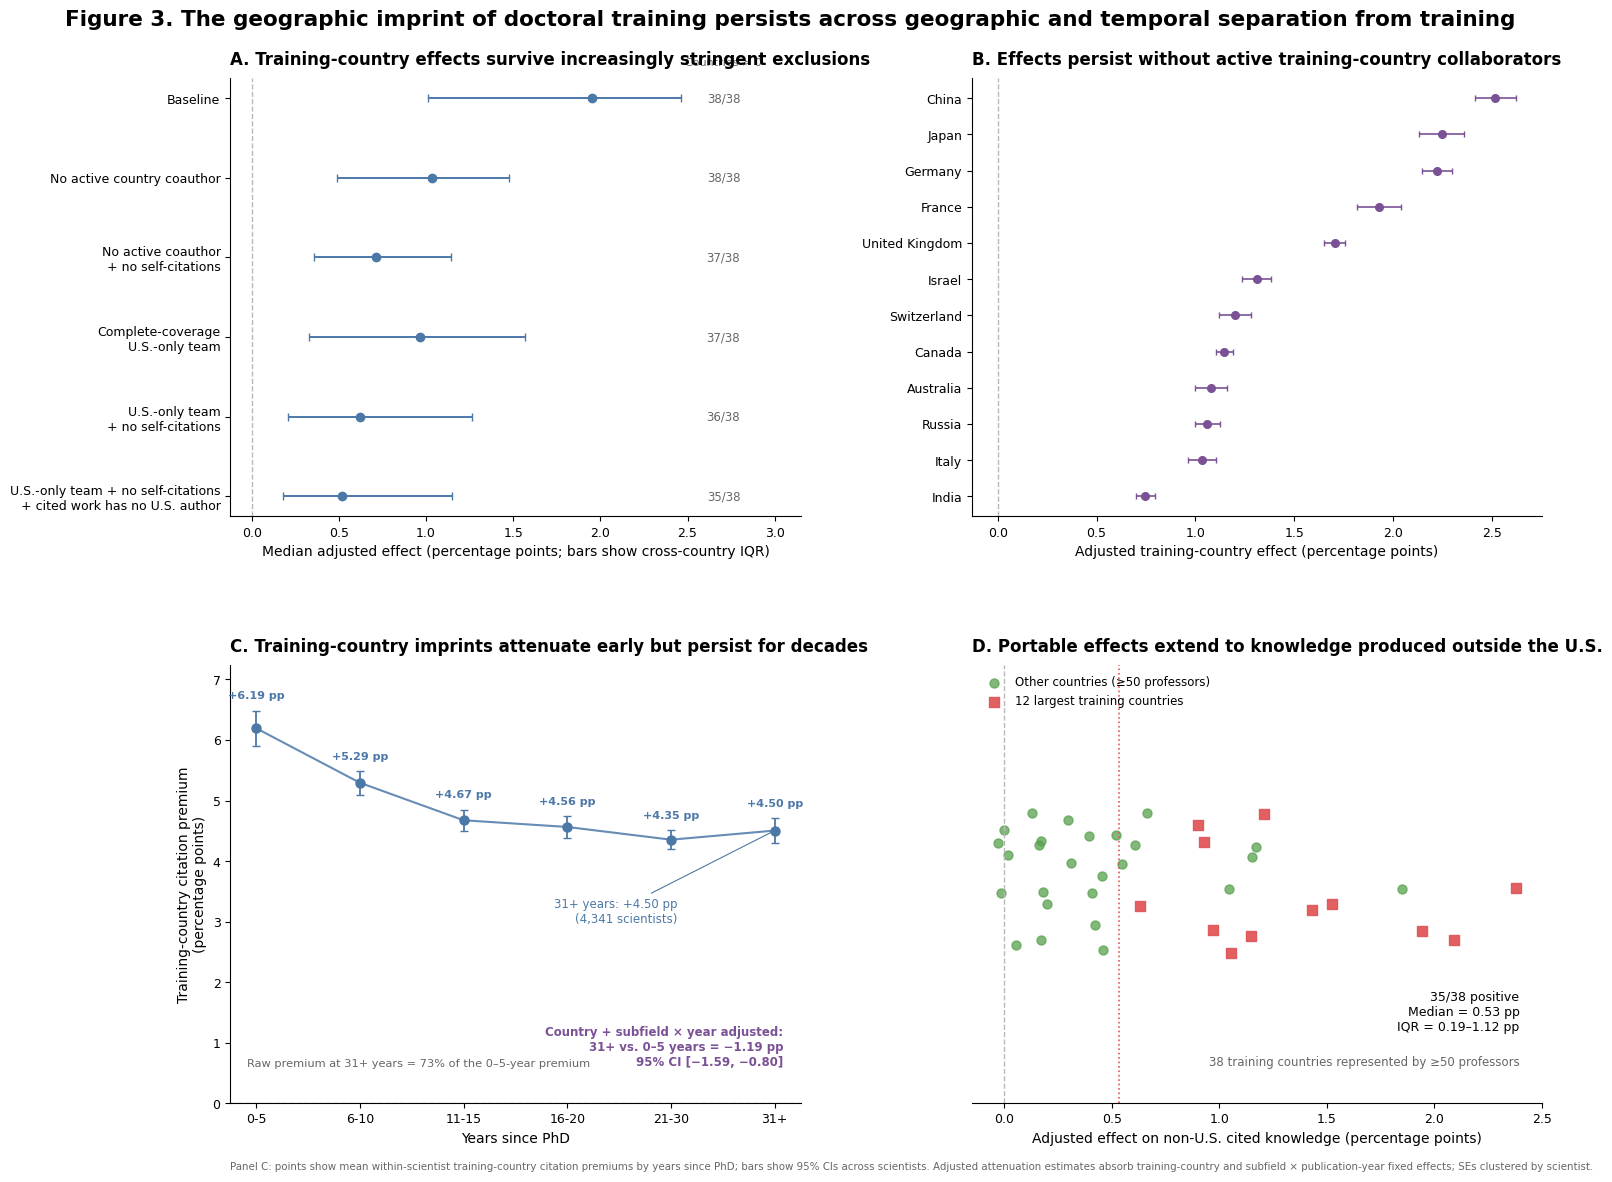

In [ ]:
# =====================================================================
# FIGURE 3
# PERSISTENCE AND PORTABILITY OF THE TRAINING-COUNTRY KNOWLEDGE IMPRINT
#
# A. Effects survive increasingly stringent exclusions
# B. Effects persist without active training-country collaborators
# C. Training-country imprints attenuate early but persist for decades
# D. Portable effects extend to knowledge produced outside the U.S.
#
# PANEL C:
#   Raw training-country premium by years since PhD
#   + scientist-clustered 95% CIs
#   + FE-adjusted attenuation relative to 0-5 years
#
# =====================================================================


from google.cloud import bigquery

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =====================================================================
# 1. CONNECT + LOAD
# =====================================================================

client = bigquery.Client(
    project="foreign-phd"
)


# ---------------------------------------------------------------------
# Existing Figure 3 results
# ---------------------------------------------------------------------

results = client.query("""
SELECT *
FROM `foreign-phd.unitanalysis.broker2_fig3_results`
""").to_dataframe()


summary = client.query("""
SELECT *
FROM `foreign-phd.unitanalysis.broker2_fig3_spec_summary`
ORDER BY spec_order
""").to_dataframe()


top12 = client.query("""
SELECT *
FROM `foreign-phd.unitanalysis.broker2_fig3_top12`
""").to_dataframe()


top12_codes = set(
    top12["training_country_code"]
)


# ---------------------------------------------------------------------
# NEW: durability data
# ---------------------------------------------------------------------

durability = client.query("""
SELECT

  author_id,

  career_bin_order,

  career_age_bin,

  years_since_phd,

  training_country_premium

FROM
  `foreign-phd.unitanalysis.durability_final`

WHERE

  career_bin_order IS NOT NULL

  AND training_country_premium IS NOT NULL

  AND years_since_phd BETWEEN 0 AND 60
""").to_dataframe()


# =====================================================================
# 2. COLORS
# =====================================================================

BLUE = "#4C78A8"
PURPLE = "#7A5195"

GREEN = "#59A14F"
RED = "#E15759"

GRAY = "#B8B8B8"
LIGHTGRAY = "#DDDDDD"

DARKGRAY = "#666666"


# =====================================================================
# 3. PANEL A DATA
# =====================================================================

summary = (
    summary
    .sort_values("spec_order")
    .reset_index(drop=True)
    .copy()
)


short_labels = {

    "baseline":
        "Baseline",

    "no_active_coauthor":
        "No active country coauthor",

    "no_active_coauthor_no_self":
        "No active coauthor\n+ no self-citations",

    "us_only":
        "Complete-coverage\nU.S.-only team",

    "us_only_no_self":
        "U.S.-only team\n+ no self-citations",

    "us_only_no_self_nonus":
        "U.S.-only team + no self-citations\n"
        "+ cited work has no U.S. author"
}


summary["plot_label"] = (
    summary["spec_id"]
    .map(short_labels)
)


# =====================================================================
# 4. PANEL B DATA
# =====================================================================

b = (
    results[
        (
            results["spec_id"]
            ==
            "no_active_coauthor_no_self"
        )
        &
        (
            results["training_country_code"]
            .isin(top12_codes)
        )
    ]
    .sort_values(
        "difference_pp_adj",
        ascending=True
    )
    .reset_index(drop=True)
)


# =====================================================================
# 5. PANEL C DATA
#
# RAW TRAINING-COUNTRY PREMIUM BY CAREER BIN
#
# To get uncertainty without treating 398k author-papers as
# independent, first collapse to:
#
#   scientist x career-age bin
#
# Then calculate the mean and SE across scientists.
#
# This is a descriptive clustered CI, not the FE-adjusted CI.
# =====================================================================

durability["training_country_premium"] = pd.to_numeric(
    durability["training_country_premium"],
    errors="coerce"
)


durability["career_bin_order"] = pd.to_numeric(
    durability["career_bin_order"],
    errors="coerce"
)


durability = durability.dropna(
    subset=[
        "author_id",
        "career_bin_order",
        "career_age_bin",
        "training_country_premium"
    ]
).copy()


# ---------------------------------------------------------------------
# Scientist x bin means
# ---------------------------------------------------------------------

durability_scientist_bin = (

    durability

    .groupby(
        [
            "author_id",
            "career_bin_order",
            "career_age_bin"
        ],
        as_index=False
    )

    .agg(
        scientist_mean_premium=(
            "training_country_premium",
            "mean"
        )
    )
)


# ---------------------------------------------------------------------
# Bin-level means + scientist-level SE
# ---------------------------------------------------------------------

c = (

    durability_scientist_bin

    .groupby(
        [
            "career_bin_order",
            "career_age_bin"
        ],
        as_index=False
    )

    .agg(

        raw_premium=(
            "scientist_mean_premium",
            "mean"
        ),

        sd_scientist=(
            "scientist_mean_premium",
            "std"
        ),

        n_scientists=(
            "author_id",
            "nunique"
        )
    )
)


# convert to percentage points
c["raw_premium_pp"] = (
    c["raw_premium"]
    * 100
)


c["se_pp"] = (

    c["sd_scientist"]

    /

    np.sqrt(
        c["n_scientists"]
    )

    * 100
)


c["ci_low_pp"] = (
    c["raw_premium_pp"]
    -
    1.96 * c["se_pp"]
)


c["ci_high_pp"] = (
    c["raw_premium_pp"]
    +
    1.96 * c["se_pp"]
)


c = (
    c
    .sort_values("career_bin_order")
    .reset_index(drop=True)
)


# =====================================================================
# 6. PANEL C — FE-ADJUSTED ATTENUATION RESULTS
#
# These come from the AbsorbingLS model already estimated:
#
# FE:
#   training country
#   subfield x publication year
#
# SE:
#   clustered by focal scientist
#
# IMPORTANT:
# These are CHANGES RELATIVE TO 0-5 YEARS.
# They are not adjusted absolute premiums.
# =====================================================================

adjusted_attenuation = pd.DataFrame({

    "career_bin_order": [
        1, 2, 3, 4, 5, 6
    ],

    "career_age_bin": [
        "0-5",
        "6-10",
        "11-15",
        "16-20",
        "21-30",
        "31+"
    ],

    # percentage points relative to 0-5
    "attenuation_pp": [
        0.00,
        -0.71,
        -0.82,
        -1.07,
        -1.23,
        -1.19
    ],

    "ci_low_pp": [
        np.nan,
        -1.02,
        -1.23,
        -1.48,
        -1.63,
        -1.59
    ],

    "ci_high_pp": [
        np.nan,
        -0.39,
        -0.40,
        -0.66,
        -0.82,
        -0.80
    ]
})


# =====================================================================
# 7. PANEL D DATA
# =====================================================================

d = (
    results[
        results["spec_id"]
        ==
        "us_only_no_self_nonus"
    ]
    .copy()
)


d["is_top12"] = (
    d["training_country_code"]
    .isin(top12_codes)
)


n_d = len(d)


n_d_positive = int(
    (
        d["difference_pp_adj"]
        > 0
    ).sum()
)


median_d = float(
    d["difference_pp_adj"]
    .median()
)


q25_d = float(
    d["difference_pp_adj"]
    .quantile(0.25)
)


q75_d = float(
    d["difference_pp_adj"]
    .quantile(0.75)
)


# =====================================================================
# 8. DIAGNOSTICS
# =====================================================================

print(
    "FIGURE 3 SPECIFICATION SUMMARY"
)

print(
    "------------------------------"
)


print(

    summary[
        [
            "spec_order",
            "spec_label",
            "n_countries",
            "n_positive",
            "median_effect_pp",
            "q25_effect_pp",
            "q75_effect_pp",
            "total_exposed_adjusted"
        ]
    ]

    .round(3)

    .to_string(
        index=False
    )
)


print()


print(
    f"Cleanest specification: "
    f"{n_d_positive}/{n_d} countries positive"
)


print(
    f"Median clean effect: "
    f"{median_d:.3f} pp"
)


print()


print(
    "DURABILITY — RAW SCIENTIST-LEVEL BIN MEANS"
)

print(
    "------------------------------------------"
)


print(

    c[
        [
            "career_age_bin",
            "n_scientists",
            "raw_premium_pp",
            "ci_low_pp",
            "ci_high_pp"
        ]
    ]

    .round(3)

    .to_string(
        index=False
    )
)


# =====================================================================
# 9. FIGURE LAYOUT
# =====================================================================

fig, axes = plt.subplots(

    2,
    2,

    figsize=(
        16,
        12.5
    )
)


axA = axes[0, 0]
axB = axes[0, 1]

axC = axes[1, 0]
axD = axes[1, 1]


plt.subplots_adjust(

    left=0.15,
    right=0.97,

    top=0.91,
    bottom=0.09,

    wspace=0.30,
    hspace=0.34
)


# =====================================================================
# PANEL A
# ATTENUATION ACROSS SPECIFICATIONS
# =====================================================================

yA = np.arange(
    len(summary)
)


lower_A = (
    summary["median_effect_pp"]
    -
    summary["q25_effect_pp"]
)


upper_A = (
    summary["q75_effect_pp"]
    -
    summary["median_effect_pp"]
)


axA.errorbar(

    summary["median_effect_pp"],
    yA,

    xerr=np.vstack([
        lower_A,
        upper_A
    ]),

    fmt="o",

    color=BLUE,
    ecolor=BLUE,

    markersize=6,
    capsize=3,
    linewidth=1.4,

    zorder=3
)


axA.axvline(

    0,

    linestyle="--",

    linewidth=1,

    color=GRAY,

    zorder=1
)


axA.set_yticks(
    yA
)


axA.set_yticklabels(

    summary["plot_label"],

    fontsize=9
)


axA.invert_yaxis()


axA.set_xlabel(

    "Median adjusted effect "
    "(percentage points; bars show cross-country IQR)"
)


axA.set_ylabel("")


axA.set_title(

    "A. Training-country effects survive increasingly stringent exclusions",

    loc="left",

    fontweight="bold",

    pad=10
)


# ---------------------------------------------------------------------
# Positive-country count
# ---------------------------------------------------------------------

effect_max = max(

    summary["q75_effect_pp"].max(),

    summary["median_effect_pp"].max()
)


effect_min = min(

    0,

    summary["q25_effect_pp"].min()
)


effect_range = (
    effect_max
    -
    effect_min
)


count_x = (
    effect_max
    +
    0.10 * effect_range
)


for i, row in summary.iterrows():

    axA.text(

        count_x,
        i,

        f"{int(row['n_positive'])}/"
        f"{int(row['n_countries'])}",

        va="center",
        ha="center",

        fontsize=8.5,

        color=DARKGRAY
    )


axA.text(

    count_x,

    -0.38,

    "Countries > 0",

    ha="center",
    va="bottom",

    fontsize=8,

    color=DARKGRAY
)


axA.set_xlim(

    effect_min
    -
    0.05 * effect_range,

    count_x
    +
    0.18 * effect_range
)


axA.spines["top"].set_visible(False)
axA.spines["right"].set_visible(False)


# =====================================================================
# PANEL B
# TOP 12 — NO ACTIVE COUNTRY COAUTHOR + NO TEAM SELF-CITATIONS
# =====================================================================

yB = np.arange(
    len(b)
)


lower_B = (
    b["difference_pp_adj"]
    -
    b["ci95_low_pp"]
)


upper_B = (
    b["ci95_high_pp"]
    -
    b["difference_pp_adj"]
)


axB.errorbar(

    b["difference_pp_adj"],
    yB,

    xerr=np.vstack([
        lower_B,
        upper_B
    ]),

    fmt="o",

    color=PURPLE,
    ecolor=PURPLE,

    markersize=5.5,
    capsize=2.5,
    linewidth=1.2,

    zorder=3
)


axB.axvline(

    0,

    linestyle="--",

    linewidth=1,

    color=GRAY
)


axB.set_yticks(
    yB
)


axB.set_yticklabels(

    b["training_country"],

    fontsize=9
)


axB.set_xlabel(
    "Adjusted training-country effect (percentage points)"
)


axB.set_ylabel("")


axB.set_title(

    "B. Effects persist without active training-country collaborators",

    loc="left",

    fontweight="bold",

    pad=10
)


axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)


# =====================================================================
# PANEL C
# DURABILITY
# =====================================================================

xC = np.arange(
    len(c)
)


# ---------------------------------------------------------------------
# 95% CIs
# ---------------------------------------------------------------------

lower_C = (
    c["raw_premium_pp"]
    -
    c["ci_low_pp"]
)


upper_C = (
    c["ci_high_pp"]
    -
    c["raw_premium_pp"]
)


# ---------------------------------------------------------------------
# Connecting line
# ---------------------------------------------------------------------

axC.plot(

    xC,

    c["raw_premium_pp"],

    color=BLUE,

    linewidth=1.5,

    alpha=0.85,

    zorder=2
)


# ---------------------------------------------------------------------
# Points + scientist-clustered descriptive CI
# ---------------------------------------------------------------------

axC.errorbar(

    xC,

    c["raw_premium_pp"],

    yerr=np.vstack([
        lower_C,
        upper_C
    ]),

    fmt="o",

    color=BLUE,
    ecolor=BLUE,

    markersize=6.5,

    capsize=3,

    linewidth=1.3,

    zorder=3
)


# ---------------------------------------------------------------------
# Zero reference
# ---------------------------------------------------------------------

axC.axhline(

    0,

    linestyle="--",

    linewidth=1,

    color=GRAY,

    zorder=1
)


# ---------------------------------------------------------------------
# Raw premium labels
# ---------------------------------------------------------------------

for i, row in c.iterrows():

    axC.text(

        i,

        row["ci_high_pp"]
        + 0.16,

        f"+{row['raw_premium_pp']:.2f} pp",

        ha="center",
        va="bottom",

        fontsize=8,

        color=BLUE,

        fontweight="bold"
    )


# ---------------------------------------------------------------------
# Career-bin labels
# ---------------------------------------------------------------------

axC.set_xticks(
    xC
)


axC.set_xticklabels(

    c["career_age_bin"],

    fontsize=9
)


# ---------------------------------------------------------------------
# Highlight long-run persistence
# ---------------------------------------------------------------------

last = c.iloc[-1]


axC.annotate(

    (
        f"31+ years: +{last['raw_premium_pp']:.2f} pp\n"
        f"({int(last['n_scientists']):,} scientists)"
    ),

    xy=(
        xC[-1],
        last["raw_premium_pp"]
    ),

    xytext=(
        -70,
        -48
    ),

    textcoords="offset points",

    ha="right",
    va="top",

    fontsize=8.5,

    color=BLUE,

    arrowprops=dict(

        arrowstyle="-",

        linewidth=0.8,

        color=BLUE
    )
)


# ---------------------------------------------------------------------
# FE-adjusted attenuation annotation
#
# We do NOT plot these as absolute adjusted levels.
# Instead show the late-career contrast explicitly.
# ---------------------------------------------------------------------

axC.text(

    0.97,
    0.08,

    (
        "Country + subfield × year adjusted:\n"
        "31+ vs. 0–5 years = −1.19 pp\n"
        "95% CI [−1.59, −0.80]"
    ),

    transform=axC.transAxes,

    ha="right",
    va="bottom",

    fontsize=8.5,

    color=PURPLE,

    fontweight="bold"
)


# ---------------------------------------------------------------------
# Optional descriptive retention statement
# ---------------------------------------------------------------------

early_raw = float(
    c.iloc[0]["raw_premium_pp"]
)


late_raw = float(
    c.iloc[-1]["raw_premium_pp"]
)


retention_pct = (
    late_raw
    /
    early_raw
    *
    100
)


axC.text(

    0.03,
    0.08,

    (
        f"Raw premium at 31+ years = "
        f"{retention_pct:.0f}% of the 0–5-year premium"
    ),

    transform=axC.transAxes,

    ha="left",
    va="bottom",

    fontsize=8.2,

    color=DARKGRAY
)


# ---------------------------------------------------------------------
# Axes
# ---------------------------------------------------------------------

axC.set_xlabel(
    "Years since PhD"
)


axC.set_ylabel(
    "Training-country citation premium\n"
    "(percentage points)"
)


axC.set_title(

    "C. Training-country imprints attenuate early but persist for decades",

    loc="left",

    fontweight="bold",

    pad=10
)


# Give labels room above the first point
c_ymax = (
    c["ci_high_pp"].max()
    + 0.75
)


axC.set_ylim(
    0,
    c_ymax
)


axC.spines["top"].set_visible(False)
axC.spines["right"].set_visible(False)


# =====================================================================
# PANEL D
# CLEANEST SPECIFICATION — ALL 38 COUNTRIES
# =====================================================================

rng = np.random.default_rng(
    42
)


d = (

    d

    .sort_values(
        "difference_pp_adj"
    )

    .reset_index(
        drop=True
    )
)


d["jitter"] = rng.uniform(

    -0.055,
    0.055,

    size=len(d)
)


other_d = d[
    ~d["is_top12"]
]


top_d = d[
    d["is_top12"]
]


axD.scatter(

    other_d["difference_pp_adj"],
    other_d["jitter"],

    s=42,

    marker="o",

    color=GREEN,

    alpha=0.75,

    label="Other countries (≥50 professors)",

    zorder=2
)


axD.scatter(

    top_d["difference_pp_adj"],
    top_d["jitter"],

    s=62,

    marker="s",

    color=RED,

    alpha=0.95,

    label="12 largest training countries",

    zorder=3
)


axD.axvline(

    0,

    linestyle="--",

    linewidth=1,

    color=GRAY
)


axD.axvline(

    median_d,

    linestyle=":",

    linewidth=1.2,

    color=RED
)


axD.set_ylim(
    -0.16,
    0.16
)


axD.set_yticks([])

axD.set_ylabel("")


axD.set_xlabel(

    "Adjusted effect on non-U.S. cited knowledge "
    "(percentage points)"
)


axD.set_title(

    "D. Portable effects extend to knowledge produced outside the U.S.",

    loc="left",

    fontweight="bold",

    pad=10
)


axD.spines["top"].set_visible(False)
axD.spines["right"].set_visible(False)
axD.spines["left"].set_visible(False)


axD.legend(

    frameon=False,

    loc="upper left",

    fontsize=8.5
)


summary_text_D = (

    f"{n_d_positive}/{n_d} positive\n"

    f"Median = {median_d:.2f} pp\n"

    f"IQR = {q25_d:.2f}–{q75_d:.2f} pp"
)


axD.text(

    0.96,
    0.16,

    summary_text_D,

    transform=axD.transAxes,

    ha="right",
    va="bottom",

    fontsize=9
)


axD.text(

    0.96,
    0.08,

    "38 training countries represented by ≥50 professors",

    transform=axD.transAxes,

    ha="right",
    va="bottom",

    fontsize=8.5,

    color=DARKGRAY
)


# =====================================================================
# 10. SHARED FORMATTING
# =====================================================================

for ax in [
    axA,
    axB,
    axC,
    axD
]:

    ax.tick_params(
        axis="both",
        labelsize=9
    )


# =====================================================================
# 11. MAIN TITLE
# =====================================================================

fig.suptitle(

    "Figure 3. The geographic imprint of doctoral training persists "
    "across geographic and temporal separation from training",

    fontsize=15.5,

    fontweight="bold",

    y=0.965
)


# =====================================================================
# 12. PANEL C METHODS NOTE
#
# Keep concise and unobtrusive.
# =====================================================================

fig.text(

    0.15,
    0.035,

    (
        "Panel C: points show mean within-scientist training-country "
        "citation premiums by years since PhD; bars show 95% CIs across "
        "scientists. Adjusted attenuation estimates absorb training-country "
        "and subfield × publication-year fixed effects; SEs clustered by "
        "scientist."
    ),

    ha="left",
    va="bottom",

    fontsize=7.4,

    color=DARKGRAY
)


# =====================================================================
# 13. DISPLAY
# =====================================================================

plt.show()


# =====================================================================
# OPTIONAL EXPORT
# =====================================================================

# fig.savefig(
#     "figure3_persistence_portability.pdf",
#     bbox_inches="tight"
# )

# fig.savefig(
#     "figure3_persistence_portability.png",
#     dpi=400,
#     bbox_inches="tight"
# )

In [ ]:
# =====================================================================
# FIGURE 4 — PANEL D ANALYSIS ONLY
#
# Run ONCE.
#
# Output:
#   figure4_panelD_results.csv
#
# This is the computationally expensive part.
# =====================================================================

from google.cloud import bigquery
from linearmodels.iv import AbsorbingLS

import pandas as pd
import numpy as np


# =====================================================================
# 1. LOAD IDENTIFYING SAMPLE ONLY
# =====================================================================

client = bigquery.Client(
    project="foreign-phd"
)

df = client.query("""
SELECT

  focal_author_id,
  focal_broker_fe,
  broker_country_year_fe,

  broker_exposure_advantage,

  matching_country_lift,
  other_foreign_lift,
  country_specific_joint_activation

FROM
  `foreign-phd.unitanalysis.broker2_fig4_plot_D_sample`

WHERE
  broker_exposure_advantage IS NOT NULL

  AND matching_country_lift IS NOT NULL

  AND other_foreign_lift IS NOT NULL

  AND country_specific_joint_activation IS NOT NULL
""").to_dataframe()


print(
    f"Loaded {len(df):,} observations"
)


# =====================================================================
# 2. TYPES
# =====================================================================

numeric_cols = [

    "broker_exposure_advantage",

    "matching_country_lift",
    "other_foreign_lift",
    "country_specific_joint_activation"
]

for col in numeric_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df.dropna().copy()


# categorical FE
df["focal_broker_fe"] = (
    df["focal_broker_fe"]
    .astype("category")
)

df["broker_country_year_fe"] = (
    df["broker_country_year_fe"]
    .astype("category")
)


# numeric cluster identifier
df["focal_cluster"] = (
    pd.factorize(
        df["focal_author_id"]
    )[0]
)


# =====================================================================
# 3. BASIC SAMPLE INFORMATION
# =====================================================================

print(
    f"Final N = {len(df):,}"
)

print(
    f"Focal scientists = "
    f"{df['focal_author_id'].nunique():,}"
)

print(
    f"Focal-broker pairs = "
    f"{df['focal_broker_fe'].nunique():,}"
)


# =====================================================================
# 4. COMMON X + FE
# =====================================================================

X = df[
    ["broker_exposure_advantage"]
].astype(float)


absorb = df[
    [
        "focal_broker_fe",
        "broker_country_year_fe"
    ]
]


clusters = df[
    "focal_cluster"
]


# =====================================================================
# 5. MODEL FUNCTION
# =====================================================================

def run_model(
    outcome,
    label
):

    print(
        f"\nFitting: {label}"
    )

    y = df[
        outcome
    ].astype(float)


    model = AbsorbingLS(

        y,
        X,

        absorb=absorb
    )


    result = model.fit(

        cov_type="clustered",

        clusters=clusters,

        use_cache=True
    )


    beta = float(
        result.params[
            "broker_exposure_advantage"
        ]
    )

    se = float(
        result.std_errors[
            "broker_exposure_advantage"
        ]
    )


    print(
        f"beta = {beta:.6f}"
    )

    print(
        f"SE = {se:.6f}"
    )


    return {

        "outcome": outcome,

        "label": label,

        "beta":
            beta,

        "se":
            se,

        "low":
            beta - 1.96 * se,

        "high":
            beta + 1.96 * se,

        "n":
            len(df)
    }


# =====================================================================
# 6. FIT MODELS
# =====================================================================

results = []


results.append(

    run_model(

        "matching_country_lift",

        "Training-country knowledge"
    )
)


results.append(

    run_model(

        "other_foreign_lift",

        "Other foreign knowledge"
    )
)


results.append(

    run_model(

        "country_specific_joint_activation",

        "Country-specific activation"
    )
)


results = pd.DataFrame(
    results
)


# =====================================================================
# 7. WITHIN-PAIR EXPOSURE SD
# =====================================================================

pair_mean = (

    df
    .groupby(
        "focal_broker_fe",
        observed=True
    )[
        "broker_exposure_advantage"
    ]
    .transform("mean")
)


within_exposure = (

    df[
        "broker_exposure_advantage"
    ]

    -

    pair_mean
)


within_sd = float(
    within_exposure.std()
)


# =====================================================================
# 8. CONVERT COEFFICIENTS TO PERCENTAGE POINTS
# =====================================================================

for col in [
    "beta",
    "se",
    "low",
    "high"
]:

    results[
        col + "_pp"
    ] = (
        results[col]
        * 100
    )


results[
    "within_exposure_sd"
] = within_sd


results[
    "effect_1sd_pp"
] = (

    results["beta"]
    * within_sd
    * 100
)


results[
    "effect_1sd_low_pp"
] = (

    results["low"]
    * within_sd
    * 100
)


results[
    "effect_1sd_high_pp"
] = (

    results["high"]
    * within_sd
    * 100
)


# =====================================================================
# 9. DISPLAY
# =====================================================================

print(
    "\nFINAL PANEL D RESULTS"
)

print(
    "---------------------"
)

print(

    results[
        [
            "label",
            "beta_pp",
            "se_pp",
            "low_pp",
            "high_pp",
            "effect_1sd_pp",
            "effect_1sd_low_pp",
            "effect_1sd_high_pp"
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)


# =====================================================================
# 10. SAVE TINY RESULT FILE
# =====================================================================

results.to_csv(
    "figure4_panelD_results.csv",
    index=False
)


print(
    "\nSaved: figure4_panelD_results.csv"
)

Loaded 103,971 observations
Final N = 103,971
Focal scientists = 14,219
Focal-broker pairs = 24,523

Fitting: Training-country knowledge
beta = 0.009658
SE = 0.001278

Fitting: Other foreign knowledge
beta = -0.000461
SE = 0.000082

Fitting: Country-specific activation
beta = 0.010119
SE = 0.001294

FINAL PANEL D RESULTS
---------------------
                      label  beta_pp  se_pp  low_pp  high_pp  effect_1sd_pp  effect_1sd_low_pp  effect_1sd_high_pp
 Training-country knowledge   0.9658 0.1278  0.7154   1.2162         0.1494             0.1107              0.1882
    Other foreign knowledge  -0.0461 0.0082 -0.0621  -0.0301        -0.0071            -0.0096             -0.0047
Country-specific activation   1.0119 0.1294  0.7583   1.2656         0.1566             0.1173              0.1958

Saved: figure4_panelD_results.csv



FIGURE 4 PANEL B — VALIDATED TEMPORAL INPUT

Training country:
 stage_order       stage  estimate      low     high
           1      Before  4.228441 4.143913 4.312969
           2 Joint paper  4.677452 4.578528 4.776377
           3       After  4.070830 4.000574 4.141086

Other foreign:
 stage_order       stage  estimate      low     high
           1      Before  1.088078 1.083319 1.092837
           2 Joint paper  1.127566 1.122388 1.132744
           3       After  1.139261 1.134486 1.144037

Training-country joint vs. pre: +0.449 pp
Training-country clean-post vs. pre: -0.158 pp
Panel D columns:
['outcome', 'label', 'beta', 'se', 'low', 'high', 'n', 'beta_pp', 'se_pp', 'low_pp', 'high_pp', 'within_exposure_sd', 'effect_1sd_pp', 'effect_1sd_low_pp', 'effect_1sd_high_pp']

Panel D labels:
['Training-country knowledge', 'Other foreign knowledge', 'Country-specific activation']


                          outcome                       label   beta_pp    se_pp    low_pp   high_pp  w

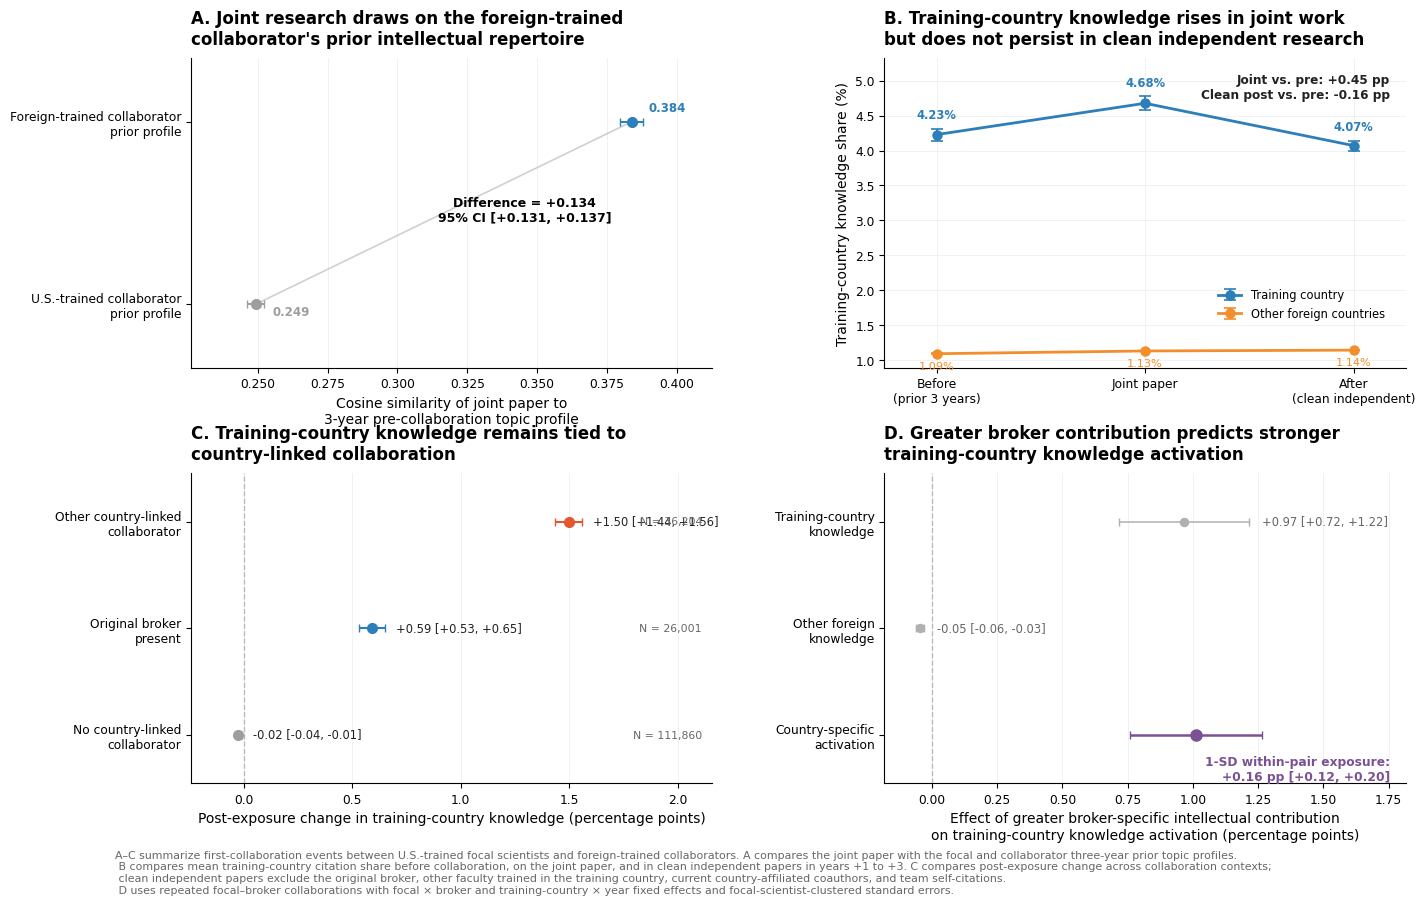


FIGURE 4 REVISED VISUALIZATION

Panel A: broker cosine = 0.384; focal cosine = 0.249; difference = +0.134
Panel B: pre = 4.23%; joint = 4.68%; post = 4.07%
Panel B: joint-pre change = +0.449 pp
Panel B: clean post-pre change = -0.158 pp

Panel C:
  No country-linked collaborator: -0.024 pp [-0.041, -0.007] (N=111,860)
  Original broker present: +0.590 pp [+0.530, +0.650] (N=26,001)
  Other country-linked collaborator present: +1.497 pp [+1.435, +1.558] (N=36,204)

Panel D: standardized 1-SD effect = +0.157 pp [+0.117, +0.196]

Saved:
figure4_results/figure4_revised_final.png
figure4_results/figure4_revised_final.pdf


In [ ]:
# =============================================================================
# FIGURE 4 — REVISED FINAL VISUALIZATION
#
# Concept:
#
# A. Joint papers reflect the foreign-trained collaborator's prior repertoire
# B. Training-country knowledge rises in joint work but does not persist
#    in clean independent post-collaboration work
# C. Training-country knowledge remains associated with country-linked
#    collaboration
# D. Greater broker-specific intellectual contribution predicts stronger
#    training-country-specific activation
#
# No new regression.
# No new bootstrap.
# Uses already validated Figure 4 backend outputs.
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from google.cloud import bigquery


# =============================================================================
# 1. SETTINGS
# =============================================================================

PROJECT = "foreign-phd"

OUTDIR = "figure4_results"

os.makedirs(
    OUTDIR,
    exist_ok=True
)

SAVE_PNG = os.path.join(
    OUTDIR,
    "figure4_revised_final.png"
)

SAVE_PDF = os.path.join(
    OUTDIR,
    "figure4_revised_final.pdf"
)

client = bigquery.Client(
    project=PROJECT
)


# =============================================================================
# 2. COLORS
#
# Match the existing Figure 4 visual grammar.
# =============================================================================

COL_BROKER = "#2C7FB8"
COL_FOCAL = "#9E9E9E"

COL_MATCH = "#2C7FB8"
COL_JOINT = "#E4572E"
COL_POST = "#7A5195"

COL_NO_LINK = "#9E9E9E"
COL_BROKER_CONTEXT = "#2C7FB8"
COL_OTHER_CONTEXT = "#E4572E"

COL_MAIN = "#7A5195"
COL_AUX = "#B0B0B0"

COL_ZERO = "#BDBDBD"
COL_CONNECT = "#D0D0D0"

COL_TEXT = "#222222"
COL_NOTE = "#666666"
COL_GRID = "#DDDDDD"


# =============================================================================
# 3. PANEL A — LOAD EXISTING RESULTS
#
# Existing notebook files:
#   figure4_panelA_ci.csv
#   figure4_panelA_diff_ci.csv
# =============================================================================

A = pd.read_csv(
    os.path.join(
        OUTDIR,
        "figure4_panelA_ci.csv"
    )
)

A_diff = pd.read_csv(
    os.path.join(
        OUTDIR,
        "figure4_panelA_diff_ci.csv"
    )
)


required_A = [
    "variable",
    "estimate",
    "low",
    "high"
]

required_A_diff = [
    "estimate",
    "low",
    "high"
]

for col in required_A:
    if col not in A.columns:
        raise ValueError(
            f"Panel A file missing column: {col}"
        )

for col in required_A_diff:
    if col not in A_diff.columns:
        raise ValueError(
            f"Panel A difference file missing column: {col}"
        )


A_broker = A.loc[
    A["variable"] == "broker"
].iloc[0]

A_focal = A.loc[
    A["variable"] == "focal"
].iloc[0]

A_difference = A_diff.iloc[0]


broker_est = float(
    A_broker["estimate"]
)

broker_low = float(
    A_broker["low"]
)

broker_high = float(
    A_broker["high"]
)

focal_est = float(
    A_focal["estimate"]
)

focal_low = float(
    A_focal["low"]
)

focal_high = float(
    A_focal["high"]
)

A_diff_est = float(
    A_difference["estimate"]
)

A_diff_low = float(
    A_difference["low"]
)

A_diff_high = float(
    A_difference["high"]
)


# =============================================================================
# 4. PANEL B — TEMPORAL COLLABORATION SEQUENCE
#
# EXISTING VALIDATED FIGURE 4 PANEL C RESULTS
#
# Source:
#   figure4_panelC_ci.csv
#
# Actual schema:
#   series
#   stage_order
#   stage
#   estimate
#   low
#   high
#
# IMPORTANT:
#   The existing file uses stage_order = 1, 2, 3.
#   We preserve that ordering rather than assuming 0, 1, 2.
# =============================================================================


C_temporal = pd.read_csv(
    os.path.join(
        OUTDIR,
        "figure4_panelC_ci.csv"
    )
)


# -----------------------------------------------------------------------------
# Validate required columns
# -----------------------------------------------------------------------------

required_temporal_cols = [
    "series",
    "stage_order",
    "stage",
    "estimate",
    "low",
    "high",
]

missing_temporal_cols = [
    col
    for col in required_temporal_cols
    if col not in C_temporal.columns
]

if missing_temporal_cols:
    raise ValueError(
        "figure4_panelC_ci.csv is missing required columns:\n"
        + "\n".join(missing_temporal_cols)
    )


# -----------------------------------------------------------------------------
# Training-country series
# -----------------------------------------------------------------------------

C_training = (
    C_temporal[
        C_temporal["series"] == "Training country"
    ]
    .sort_values("stage_order")
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# Other-foreign series
# -----------------------------------------------------------------------------

C_other = (
    C_temporal[
        C_temporal["series"] == "Other foreign"
    ]
    .sort_values("stage_order")
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# Validate number of stages
# -----------------------------------------------------------------------------

if len(C_training) != 3:
    raise ValueError(
        "Expected exactly 3 Training-country rows; "
        f"found {len(C_training)}."
    )

if len(C_other) != 3:
    raise ValueError(
        "Expected exactly 3 Other-foreign rows; "
        f"found {len(C_other)}."
    )


# -----------------------------------------------------------------------------
# DO NOT assume numeric stage_order values.
#
# The validated file uses 1, 2, 3.
# We simply use the sorted rows as the three temporal stages.
# -----------------------------------------------------------------------------

training_est = (
    C_training["estimate"]
    .to_numpy(dtype=float)
)

training_low = (
    C_training["low"]
    .to_numpy(dtype=float)
)

training_high = (
    C_training["high"]
    .to_numpy(dtype=float)
)


other_est = (
    C_other["estimate"]
    .to_numpy(dtype=float)
)

other_low = (
    C_other["low"]
    .to_numpy(dtype=float)
)

other_high = (
    C_other["high"]
    .to_numpy(dtype=float)
)


# -----------------------------------------------------------------------------
# Descriptive changes from the already-estimated point estimates
# -----------------------------------------------------------------------------

joint_change = (
    training_est[1]
    -
    training_est[0]
)

clean_post_change = (
    training_est[2]
    -
    training_est[0]
)


# -----------------------------------------------------------------------------
# Print exact source data
# -----------------------------------------------------------------------------

print()
print("=" * 100)
print("FIGURE 4 PANEL B — VALIDATED TEMPORAL INPUT")
print("=" * 100)
print()

print("Training country:")
print(
    C_training[
        [
            "stage_order",
            "stage",
            "estimate",
            "low",
            "high",
        ]
    ].to_string(index=False)
)

print()

print("Other foreign:")
print(
    C_other[
        [
            "stage_order",
            "stage",
            "estimate",
            "low",
            "high",
        ]
    ].to_string(index=False)
)

print()

print(
    f"Training-country joint vs. pre: "
    f"{joint_change:+.3f} pp"
)

print(
    f"Training-country clean-post vs. pre: "
    f"{clean_post_change:+.3f} pp"
)

# =============================================================================
# 5. PANEL C — EXISTING COLLABORATION-CONTEXT RESULTS
#
# Existing validated table:
#   broker2_fig4_context_results
#
# Values:
#   No country-linked collaborator
#   Original broker present
#   Other country-linked collaborator present
# =============================================================================

query_C = """
SELECT

    collaboration_context,

    n_focal_country_pairs,

    effect_pp,

    se_pp,

    ci95_low_pp,

    ci95_high_pp

FROM
    `foreign-phd.unitanalysis.broker2_fig4_context_results`

ORDER BY

    CASE

        WHEN collaboration_context =
            'No country-linked collaborator'
        THEN 1

        WHEN collaboration_context =
            'Original broker present'
        THEN 2

        WHEN collaboration_context =
            'Other country-linked collaborator present'
        THEN 3

        ELSE 99

    END
"""

C = (
    client
    .query(query_C)
    .to_dataframe()
)


required_C = [
    "collaboration_context",
    "n_focal_country_pairs",
    "effect_pp",
    "se_pp",
    "ci95_low_pp",
    "ci95_high_pp"
]

for col in required_C:
    if col not in C.columns:
        raise ValueError(
            f"Panel C missing column: {col}"
        )


# =============================================================================
# PANEL D — EXISTING MODEL RESULTS
# =============================================================================

D = pd.read_csv(
    os.path.join(
        OUTDIR,
        "figure4_panelD_results.csv"
    )
)

print("Panel D columns:")
print(D.columns.tolist())
print()

print("Panel D labels:")
print(D["label"].tolist())
print()


# -----------------------------------------------------------------------------
# Validate required columns
# -----------------------------------------------------------------------------

required_D = [
    "outcome",
    "label",
    "beta",
    "se",
    "low",
    "high",
    "n",
    "beta_pp",
    "se_pp",
    "low_pp",
    "high_pp",
    "within_exposure_sd",
    "effect_1sd_pp",
    "effect_1sd_low_pp",
    "effect_1sd_high_pp",
]

missing_D = [
    col
    for col in required_D
    if col not in D.columns
]

if missing_D:
    raise ValueError(
        "Panel D missing required columns:\n"
        + "\n".join(missing_D)
    )


# -----------------------------------------------------------------------------
# EXACT labels from the actual CSV
# -----------------------------------------------------------------------------

expected_labels = {
    "Training-country knowledge",
    "Other foreign knowledge",
    "Country-specific activation",
}

observed_labels = set(
    D["label"]
    .dropna()
    .astype(str)
)

missing_labels = (
    expected_labels
    -
    observed_labels
)

if missing_labels:
    raise ValueError(
        "Panel D is missing expected labels:\n"
        + "\n".join(sorted(missing_labels))
    )


# -----------------------------------------------------------------------------
# Manuscript display labels
# -----------------------------------------------------------------------------

plot_label_map = {
    "Training-country knowledge":
        "Training-country\nknowledge",

    "Other foreign knowledge":
        "Other foreign\nknowledge",

    "Country-specific activation":
        "Country-specific\nactivation",
}


D["plot_label"] = (
    D["label"]
    .map(plot_label_map)
    .fillna(D["label"])
)


# -----------------------------------------------------------------------------
# Plot ordering
# -----------------------------------------------------------------------------

D["plot_order"] = (
    D["label"]
    .map({
        "Training-country knowledge": 0,
        "Other foreign knowledge": 1,
        "Country-specific activation": 2,
    })
)

D = (
    D
    .sort_values("plot_order")
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# Primary standardized 1-SD effect
# -----------------------------------------------------------------------------

D_main = D.loc[
    D["label"] == "Country-specific activation"
].iloc[0]


one_sd = float(
    D_main["effect_1sd_pp"]
)

one_sd_low = float(
    D_main["effect_1sd_low_pp"]
)

one_sd_high = float(
    D_main["effect_1sd_high_pp"]
)


# -----------------------------------------------------------------------------
# Validation
# -----------------------------------------------------------------------------

print()
print(
    D[
        [
            "outcome",
            "label",
            "beta_pp",
            "se_pp",
            "low_pp",
            "high_pp",
            "within_exposure_sd",
            "effect_1sd_pp",
            "effect_1sd_low_pp",
            "effect_1sd_high_pp",
            "n",
        ]
    ].to_string(index=False)
)

print()

print(
    "Panel D standardized 1-SD effect:",
    f"{one_sd:+.3f} pp",
    f"[{one_sd_low:+.3f}, {one_sd_high:+.3f}]"
)
# =============================================================================
# 7. FIGURE
# =============================================================================

fig, axes = plt.subplots(

    2,
    2,

    figsize=(13.8, 9.3),

    gridspec_kw={
        "hspace": 0.34,
        "wspace": 0.33
    }
)

axA = axes[0, 0]
axB = axes[0, 1]
axC = axes[1, 0]
axD = axes[1, 1]


# =============================================================================
# PANEL A
# =============================================================================

yA = np.array([
    1,
    0
])

xA = np.array([
    broker_est,
    focal_est
])

lowA = np.array([
    broker_low,
    focal_low
])

highA = np.array([
    broker_high,
    focal_high
])

labelsA = [
    "Foreign-trained collaborator\nprior profile",
    "U.S.-trained collaborator\nprior profile"
]

colorsA = [
    COL_BROKER,
    COL_FOCAL
]


for i in range(2):

    axA.errorbar(

        xA[i],

        yA[i],

        xerr=np.array([
            [xA[i] - lowA[i]],
            [highA[i] - xA[i]]
        ]),

        fmt="o",

        markersize=7,

        capsize=3,

        linewidth=1.4,

        color=colorsA[i],

        ecolor=colorsA[i],

        zorder=3
    )


# Connector between the two estimates
axA.plot(

    [focal_est, broker_est],

    [0, 1],

    color=COL_CONNECT,

    linewidth=1.2,

    zorder=1
)


axA.set_yticks(yA)

axA.set_yticklabels(
    labelsA
)


axA.set_xlabel(
    "Cosine similarity of joint paper to\n"
    "3-year pre-collaboration topic profile"
)


axA.set_title(

    "A. Joint research draws on the foreign-trained\n"
    "collaborator's prior intellectual repertoire",

    loc="left",

    fontweight="bold",

    pad=10
)


# Difference annotation

axA.text(

    0.64,

    0.51,

    (
        f"Difference = {A_diff_est:+.3f}\n"
        f"95% CI [{A_diff_low:+.3f}, {A_diff_high:+.3f}]"
    ),

    transform=axA.transAxes,

    ha="center",

    va="center",

    fontsize=9,

    fontweight="bold"
)


# Direct values

axA.text(

    broker_est + 0.006,

    1.06,

    f"{broker_est:.3f}",

    fontsize=8.5,

    color=COL_BROKER,

    fontweight="bold"
)

axA.text(

    focal_est + 0.006,

    -0.06,

    f"{focal_est:.3f}",

    fontsize=8.5,

    color=COL_FOCAL,

    fontweight="bold"
)


axA.set_xlim(

    min(focal_low, broker_low) - 0.02,

    max(focal_high, broker_high) + 0.025
)

axA.set_ylim(
    -0.35,
    1.35
)


# =============================================================================
# PANEL B — TEMPORAL LOCALIZATION
#
# Validated estimates and 95% CIs from:
#     figure4_panelC_ci.csv
#
# Training country:
#     Before      4.228 [4.144, 4.313]
#     Joint       4.677 [4.579, 4.776]
#     After       4.071 [4.001, 4.141]
#
# Other foreign:
#     Before      1.088 [1.083, 1.093]
#     Joint       1.128 [1.122, 1.133]
#     After       1.139 [1.134, 1.144]
# =============================================================================


# -----------------------------------------------------------------------------
# Ensure the Figure 4 colors exist
# -----------------------------------------------------------------------------

COL_MATCH = "#2C7FB8"
COL_OTHER = "#F28E2B"
COL_CONNECT = "#D0D0D0"
COL_TEXT = "#222222"
COL_NOTE = "#666666"


# =============================================================================
# 1. X POSITIONS
# =============================================================================

xB = np.arange(3)


# =============================================================================
# 2. ERROR BARS
# =============================================================================

training_yerr = np.vstack([
    training_est - training_low,
    training_high - training_est,
])


other_yerr = np.vstack([
    other_est - other_low,
    other_high - other_est,
])


# =============================================================================
# 3. TRAINING-COUNTRY SERIES
# =============================================================================

axB.errorbar(

    xB,

    training_est,

    yerr=training_yerr,

    fmt="o-",

    markersize=6.5,

    linewidth=2.0,

    capsize=4,

    capthick=1.2,

    elinewidth=1.3,

    color=COL_MATCH,

    ecolor=COL_MATCH,

    zorder=4,

    label="Training country",
)


# =============================================================================
# 4. OTHER-FOREIGN SERIES
# =============================================================================

axB.errorbar(

    xB,

    other_est,

    yerr=other_yerr,

    fmt="o-",

    markersize=6.5,

    linewidth=2.0,

    capsize=4,

    capthick=1.2,

    elinewidth=1.3,

    color=COL_OTHER,

    ecolor=COL_OTHER,

    zorder=4,

    label="Other foreign countries",
)


# =============================================================================
# 5. X AXIS
# =============================================================================

axB.set_xticks(
    xB
)

axB.set_xticklabels([
    "Before\n(prior 3 years)",
    "Joint paper",
    "After\n(clean independent)",
])


# =============================================================================
# 6. Y AXIS
# =============================================================================

axB.set_ylabel(
    "Training-country knowledge share (%)"
)


# =============================================================================
# 7. POINT LABELS
# =============================================================================
#
# Show point estimates only.
# 95% CIs are fully represented by the error bars.
# -----------------------------------------------------------------------------

for i in range(3):

    axB.text(

        xB[i],

        training_high[i] + 0.10,

        f"{training_est[i]:.2f}%",

        ha="center",

        va="bottom",

        fontsize=8.3,

        color=COL_MATCH,

        fontweight="bold",

        zorder=5,
    )


for i in range(3):

    axB.text(

        xB[i],

        other_low[i] - 0.10,

        f"{other_est[i]:.2f}%",

        ha="center",

        va="top",

        fontsize=8.1,

        color=COL_OTHER,

        zorder=5,
    )


# =============================================================================
# 8. KEY CHANGES
# =============================================================================

joint_change = (
    training_est[1]
    -
    training_est[0]
)

clean_post_change = (
    training_est[2]
    -
    training_est[0]
)


axB.text(

    0.97,

    0.95,

    (
        f"Joint vs. pre: {joint_change:+.2f} pp\n"
        f"Clean post vs. pre: {clean_post_change:+.2f} pp"
    ),

    transform=axB.transAxes,

    ha="right",

    va="top",

    fontsize=8.7,

    color=COL_TEXT,

    fontweight="bold",

    zorder=6,
)


# =============================================================================
# 9. TITLE
# =============================================================================

axB.set_title(

    "B. Training-country knowledge rises in joint work\n"
    "but does not persist in clean independent research",

    loc="left",

    fontweight="bold",

    pad=10,
)


# =============================================================================
# 10. LEGEND
# =============================================================================

axB.legend(
    frameon=False,
    loc="lower right",
    bbox_to_anchor=(0.98, 0.12),
    fontsize=8.3,
)


# =============================================================================
# 11. AXIS LIMITS
# =============================================================================

all_low = np.concatenate([
    training_low,
    other_low,
])

all_high = np.concatenate([
    training_high,
    other_high,
])


axB.set_xlim(
    -0.25,
    2.25,
)


axB.set_ylim(

    max(
        0,
        all_low.min() - 0.20,
    ),

    all_high.max() + 0.55,
)


# =============================================================================
# 12. GRID / SPINES
# =============================================================================

axB.grid(

    axis="x",

    linewidth=0.6,

    alpha=0.18,
)

axB.grid(

    axis="y",

    linewidth=0.6,

    alpha=0.18,
)

axB.spines[
    "top"
].set_visible(False)

axB.spines[
    "right"
].set_visible(False)


# =============================================================================
# 13. FINAL VALIDATION
# =============================================================================

print()
print("=" * 90)
print("PANEL B PLOTTED")
print("=" * 90)
print()

for i in range(3):

    print(
        f"Training country | "
        f"{C_training.iloc[i]['stage']} | "
        f"{training_est[i]:.3f} "
        f"[{training_low[i]:.3f}, {training_high[i]:.3f}]"
    )

print()

for i in range(3):

    print(
        f"Other foreign    | "
        f"{C_other.iloc[i]['stage']} | "
        f"{other_est[i]:.3f} "
        f"[{other_low[i]:.3f}, {other_high[i]:.3f}]"
    )
# =============================================================================
# PANEL C
#
# This replaces the old clean-post Panel C with the context test.
# =============================================================================

context_order = [
    "No country-linked collaborator",
    "Original broker present",
    "Other country-linked collaborator present"
]

context_labels = [
    "No country-linked\ncollaborator",
    "Original broker\npresent",
    "Other country-linked\ncollaborator"
]


C_plot = (
    C
    .set_index("collaboration_context")
    .reindex(context_order)
    .reset_index()
)


yC = np.array([
    0,
    1,
    2
])


context_colors = [
    COL_NO_LINK,
    COL_BROKER_CONTEXT,
    COL_OTHER_CONTEXT
]


for i, row in C_plot.iterrows():

    estimate = float(
        row["effect_pp"]
    )

    low = float(
        row["ci95_low_pp"]
    )

    high = float(
        row["ci95_high_pp"]
    )


    axC.errorbar(

        estimate,

        yC[i],

        xerr=np.array([
            [estimate - low],
            [high - estimate]
        ]),

        fmt="o",

        markersize=7,

        capsize=3,

        linewidth=1.5,

        color=context_colors[i],

        ecolor=context_colors[i],

        zorder=3
    )


axC.axvline(

    0,

    linestyle="--",

    linewidth=1,

    color=COL_ZERO,

    zorder=0
)


axC.set_yticks(
    yC
)

axC.set_yticklabels(
    context_labels
)


axC.set_xlabel(
    "Post-exposure change in training-country knowledge (percentage points)"
)


axC.set_title(

    "C. Training-country knowledge remains tied to\n"
    "country-linked collaboration",

    loc="left",

    fontweight="bold",

    pad=10
)


# Direct estimates

for i, row in C_plot.iterrows():

    estimate = float(
        row["effect_pp"]
    )

    low = float(
        row["ci95_low_pp"]
    )

    high = float(
        row["ci95_high_pp"]
    )

    axC.text(

        high + 0.05,

        yC[i],

        (
            f"{estimate:+.2f} "
            f"[{low:+.2f}, {high:+.2f}]"
        ),

        va="center",

        fontsize=8.3,

        color=COL_TEXT
    )


# N annotations

for i, row in C_plot.iterrows():

    n = int(
        row["n_focal_country_pairs"]
    )

    axC.text(

        0.98,

        yC[i],

        f"N = {n:,}",

        transform=axC.get_yaxis_transform(),

        ha="right",

        va="center",

        fontsize=7.8,

        color=COL_NOTE
    )


C_min = min(
    0,
    C_plot["ci95_low_pp"].min()
)

C_max = max(
    0,
    C_plot["ci95_high_pp"].max()
)


axC.set_xlim(

    C_min - 0.20,

    C_max + 0.60
)

axC.set_ylim(
    -0.45,
    2.45
)


# =============================================================================
# PANEL D
# =============================================================================

yD = np.array([
    2,
    1,
    0
])


# Existing D contains:
#   Training-country activation
#   Other-foreign activation
#   Country-specific activation

for i, row in D.iterrows():

    beta = float(
        row["beta_pp"]
    )

    low = float(
        row["low_pp"]
    )

    high = float(
        row["high_pp"]
    )


    if row["label"] == "Country-specific activation":

        color = COL_MAIN
        size = 8
        width = 1.8

    else:

        color = COL_AUX
        size = 5.8
        width = 1.1


    axD.errorbar(

        beta,

        yD[i],

        xerr=np.array([
            [beta - low],
            [high - beta]
        ]),

        fmt="o",

        markersize=size,

        capsize=3,

        linewidth=width,

        color=color,

        ecolor=color,

        zorder=3
    )


axD.axvline(

    0,

    linestyle="--",

    linewidth=1,

    color=COL_ZERO,

    zorder=0
)


axD.set_yticks(
    yD
)

axD.set_yticklabels(
    D["plot_label"]
)


axD.set_xlabel(

    "Effect of greater broker-specific intellectual contribution\n"
    "on training-country knowledge activation (percentage points)"
)


axD.set_title(

    "D. Greater broker contribution predicts stronger\n"
    "training-country knowledge activation",

    loc="left",

    fontweight="bold",

    pad=10
)


# Supporting estimates

for i, row in D.iterrows():

    if row["label"] == "Country-specific activation":
        continue

    beta = float(
        row["beta_pp"]
    )

    low = float(
        row["low_pp"]
    )

    high = float(
        row["high_pp"]
    )

    axD.text(

        high + 0.05,

        yD[i],

        (
            f"{beta:+.2f} "
            f"[{low:+.2f}, {high:+.2f}]"
        ),

        va="center",

        fontsize=8.3,

        color=COL_NOTE
    )


# Standardized primary effect

axD.text(

    0.97,

    0.0,

    (
        "1-SD within-pair exposure:\n"
        f"{one_sd:+.2f} pp "
        f"[{one_sd_low:+.2f}, {one_sd_high:+.2f}]"
    ),

    transform=axD.transAxes,

    ha="right",

    va="bottom",

    fontsize=8.8,

    color=COL_MAIN,

    fontweight="bold"
)


D_min = min(
    0,
    D["low_pp"].min()
)

D_max = max(
    0,
    D["high_pp"].max()
)


axD.set_xlim(

    D_min - 0.12,

    D_max + 0.55
)

axD.set_ylim(
    -0.45,
    2.45
)


# =============================================================================
# 8. SHARED FORMATTING
# =============================================================================

for ax in axes.flat:

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=8.8
    )

    ax.grid(

        axis="x",

        linewidth=0.6,

        alpha=0.20
    )


# Do not show vertical grid on Panel A
axA.grid(
    axis="y",
    visible=False
)




# =============================================================================
# 11. FOOTNOTE
# =============================================================================

fig.text(

    0.05,

    -0.015,

    (
        "A–C summarize first-collaboration events between U.S.-trained focal "
        "scientists and foreign-trained collaborators. A compares the joint "
        "paper with the focal and collaborator three-year prior topic profiles.\n "
        "B compares mean training-country citation share before collaboration, "
        "on the joint paper, and in clean independent papers in years +1 to +3. "
        "C compares post-exposure change across collaboration contexts; \n clean "
        "independent papers exclude the original broker, other faculty trained "
        "in the training country, current country-affiliated coauthors, and team "
        "self-citations. \n D uses repeated focal–broker collaborations with "
        "focal × broker and training-country × year fixed effects and "
        "focal-scientist-clustered standard errors."
    ),

    fontsize=7.9,

    color=COL_NOTE,

    ha="left",

    va="bottom"
)


# =============================================================================
# 12. LAYOUT
# =============================================================================

fig.subplots_adjust(

    left=0.105,

    right=0.985,

    top=0.885,

    bottom=0.105
)


# =============================================================================
# 13. SAVE
# =============================================================================

fig.savefig(

    SAVE_PNG,

    dpi=600,

    bbox_inches="tight"
)

fig.savefig(

    SAVE_PDF,

    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# =============================================================================
# 14. VALIDATION PRINT
# =============================================================================

print()
print("=" * 90)
print("FIGURE 4 REVISED VISUALIZATION")
print("=" * 90)
print()

print(
    f"Panel A: broker cosine = {broker_est:.3f}; "
    f"focal cosine = {focal_est:.3f}; "
    f"difference = {A_diff_est:+.3f}"
)

print(
    f"Panel B: pre = {B_pre * 100:.2f}%; "
    f"joint = {B_joint * 100:.2f}%; "
    f"post = {B_post * 100:.2f}%"
)

print(
    f"Panel B: joint-pre change = "
    f"{B_joint_change_mean:+.3f} pp"
)

print(
    f"Panel B: clean post-pre change = "
    f"{B_post_change_mean:+.3f} pp"
)

print()

print(
    "Panel C:"
)

for _, row in C_plot.iterrows():

    print(
        f"  {row['collaboration_context']}: "
        f"{row['effect_pp']:+.3f} pp "
        f"[{row['ci95_low_pp']:+.3f}, "
        f"{row['ci95_high_pp']:+.3f}] "
        f"(N={int(row['n_focal_country_pairs']):,})"
    )

print()

print(
    f"Panel D: standardized 1-SD effect = "
    f"{one_sd:+.3f} pp "
    f"[{one_sd_low:+.3f}, {one_sd_high:+.3f}]"
)

print()
print("Saved:")
print(SAVE_PNG)
print(SAVE_PDF)

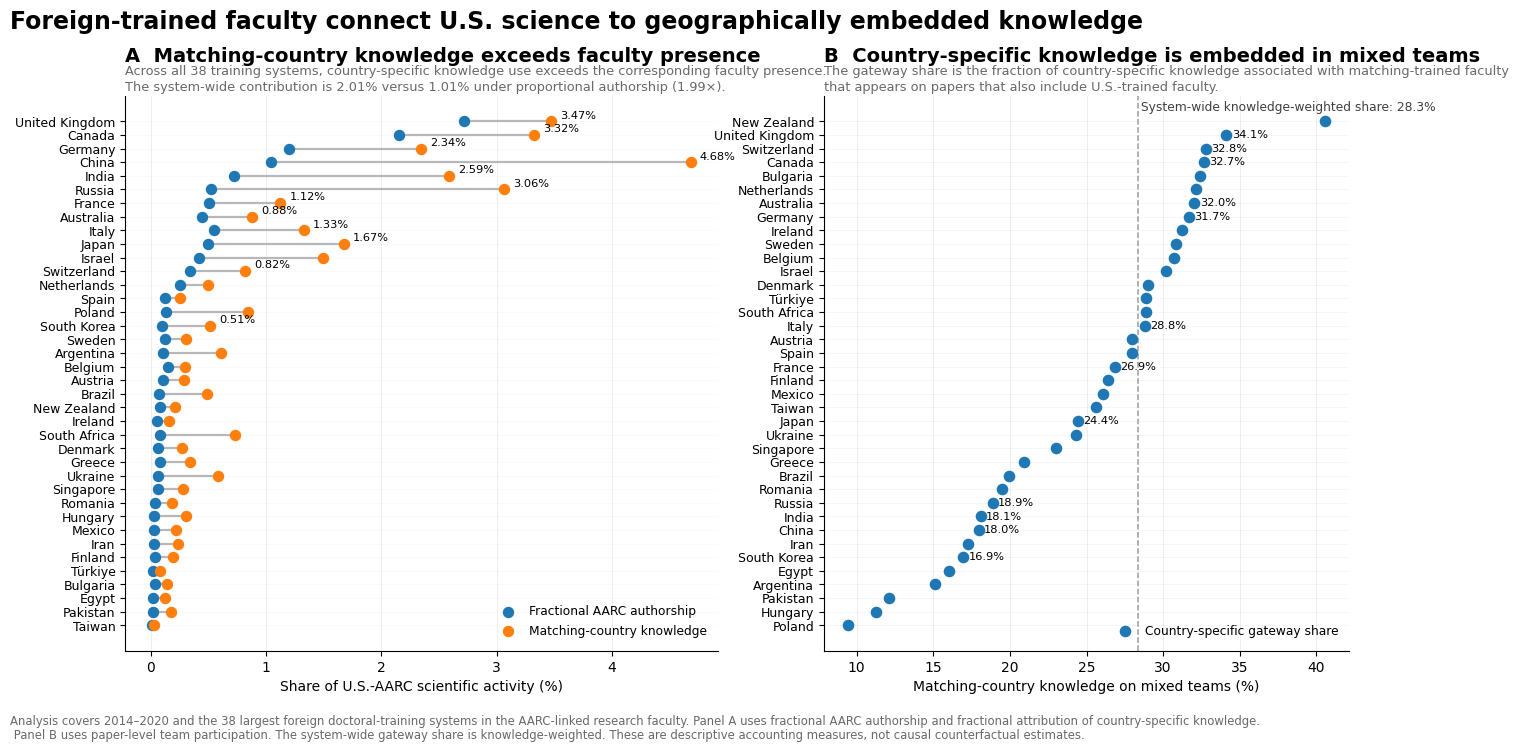


FIGURE 5 KEY RESULTS

Observed matching-country knowledge contribution: 2.01%
Expected under proportional authorship: 1.01%
Knowledge amplification: 1.99x
Knowledge-weighted collaborative gateway: 28.35%
Country-level gateway range: 9.4%–40.6%
Country-level gateway median: 26.6%

Saved:
figure5_revised/Figure5_system_level_knowledge_connectivity.png
figure5_revised/Figure5_system_level_knowledge_connectivity.pdf


In [ ]:
# =============================================================================
# FIGURE 5 — SYSTEM-LEVEL KNOWLEDGE CONNECTIVITY
# REVISED VISUALIZATION
#
# Requested revisions:
#   1. Move subtitles upward, directly under panel titles.
#   2. Split each subtitle into two lines.
#   3. Put both legends in the lower-right of their panels.
#   4. Use one consistent neutral color for the connecting lines in Panel A.
#
# Visual grammar follows the existing main figures:
#   - white background
#   - bold left-aligned titles
#   - blue/orange substantive series
#   - neutral gray connecting lines
#   - light grids
#   - minimal spines
#   - direct annotations
# =============================================================================


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.cloud import bigquery


# =============================================================================
# 1. SETTINGS
# =============================================================================

PROJECT = "foreign-phd"

OUTDIR = "figure5_revised"

os.makedirs(
    OUTDIR,
    exist_ok=True
)

client = bigquery.Client(
    project=PROJECT
)


# =============================================================================
# 2. LOAD COUNTRY DATA
# =============================================================================

query_country = """
SELECT

    degree_country_rank,
    country,
    country_code,
    n_matching_trained_professors,

    authorship_share,
    matching_knowledge_share,
    knowledge_to_presence_ratio,

    collaborative_gateway_share,

    total_country_knowledge,
    matching_country_knowledge,
    matching_participation_knowledge,
    mixed_team_matching_knowledge,

    n_matching_participation_papers,
    n_mixed_team_papers

FROM
    `foreign-phd.unitanalysis.fig5_revised_country`

ORDER BY
    degree_country_rank
"""

country = (
    client
    .query(query_country)
    .to_dataframe()
)


# =============================================================================
# 3. LOAD SYSTEM DATA
# =============================================================================

query_system = """
SELECT

    observed_matching_share,
    expected_matching_share,
    knowledge_amplification,

    system_collaborative_gateway_share,

    system_mixed_team_share_all_country_knowledge,

    excess_matching_knowledge,

    share_of_observed_matching_contribution_above_benchmark

FROM
    `foreign-phd.unitanalysis.fig5_revised_system`
"""

system = (
    client
    .query(query_system)
    .to_dataframe()
    .iloc[0]
)


# =============================================================================
# 4. VALIDATION
# =============================================================================

if len(country) != 38:
    raise ValueError(
        f"Expected 38 training systems; found {len(country)}."
    )


required_cols = [
    "degree_country_rank",
    "country",
    "country_code",
    "authorship_share",
    "matching_knowledge_share",
    "knowledge_to_presence_ratio",
    "collaborative_gateway_share",
]

missing = [
    col for col in required_cols
    if col not in country.columns
]

if missing:
    raise ValueError(
        "Missing required columns:\n"
        + "\n".join(missing)
    )


# =============================================================================
# 5. DERIVED VARIABLES
# =============================================================================

country["authorship_pct"] = (
    100 *
    country["authorship_share"]
)

country["matching_knowledge_pct"] = (
    100 *
    country["matching_knowledge_share"]
)

country["gateway_pct"] = (
    100 *
    country["collaborative_gateway_share"]
)


country = (
    country
    .sort_values("degree_country_rank")
    .reset_index(drop=True)
)


# =============================================================================
# 6. COUNTRIES TO LABEL
#
# Keep direct labels selective to preserve the clean PNAS-style appearance.
# =============================================================================

label_countries = {
    "United Kingdom",
    "Canada",
    "Germany",
    "China",
    "India",
    "Russia",
    "France",
    "Australia",
    "Italy",
    "Japan",
    "Switzerland",
    "South Korea",
}


# =============================================================================
# 7. FIGURE
# =============================================================================

fig, axes = plt.subplots(

    1,
    2,

    figsize=(14.4, 7.2),

    gridspec_kw={
        "width_ratios": [1.06, 0.94],
        "wspace": 0.19,
    }
)


# =============================================================================
# PANEL A
# =============================================================================

ax = axes[0]

plot_df = country.copy()

plot_df["y"] = (
    len(plot_df)
    - 1
    - np.arange(len(plot_df))
)


# -----------------------------------------------------------------------------
# Consistent connector color
#
# Neutral gray matches the paired-dot grammar used in the other figures.
# -----------------------------------------------------------------------------

connector_color = "0.72"


for _, row in plot_df.iterrows():

    ax.plot(

        [
            row["authorship_pct"],
            row["matching_knowledge_pct"]
        ],

        [
            row["y"],
            row["y"]
        ],

        color=connector_color,

        linewidth=1.6,

        solid_capstyle="round",

        zorder=1
    )


# -----------------------------------------------------------------------------
# BLUE — fractional AARC authorship
# -----------------------------------------------------------------------------

ax.scatter(

    plot_df["authorship_pct"],

    plot_df["y"],

    s=52,

    zorder=3,

    label="Fractional AARC authorship"
)


# -----------------------------------------------------------------------------
# ORANGE — matching-country knowledge
# -----------------------------------------------------------------------------

ax.scatter(

    plot_df["matching_knowledge_pct"],

    plot_df["y"],

    s=52,

    zorder=3,

    label="Matching-country knowledge"
)


# -----------------------------------------------------------------------------
# Y AXIS
# -----------------------------------------------------------------------------

ax.set_yticks(
    plot_df["y"]
)

ax.set_yticklabels(
    plot_df["country"],
    fontsize=9
)


# -----------------------------------------------------------------------------
# X AXIS
# -----------------------------------------------------------------------------

ax.set_xlabel(

    "Share of U.S.-AARC scientific activity (%)",

    fontsize=10
)


# -----------------------------------------------------------------------------
# DIRECT VALUE LABELS
# -----------------------------------------------------------------------------

for _, row in plot_df.iterrows():

    if row["country"] not in label_countries:
        continue

    x = max(
        row["authorship_pct"],
        row["matching_knowledge_pct"]
    )

    ax.text(

        x + 0.08,

        row["y"] + 0.07,

        f"{x:.2f}%",

        fontsize=8.2,

        va="bottom",

        ha="left"
    )


# -----------------------------------------------------------------------------
# PANEL TITLE
# -----------------------------------------------------------------------------

ax.set_title(

    "A  Matching-country knowledge exceeds faculty presence",

    loc="left",

    fontsize=14,

    fontweight="bold",

    pad=25
)


# -----------------------------------------------------------------------------
# TWO-LINE SUBTITLE
#
# Put subtitle inside the axes, immediately below title.
# -----------------------------------------------------------------------------

ax.text(

    0,

    1.005,

    (
        "Across all 38 training systems, country-specific knowledge use "
        "exceeds the corresponding faculty presence.\n"
        "The system-wide contribution is 2.01% versus 1.01% under "
        "proportional authorship (1.99×)."
    ),

    transform=ax.transAxes,

    fontsize=9.3,

    color="dimgray",

    ha="left",

    va="bottom",

    linespacing=1.25
)


# -----------------------------------------------------------------------------
# PANEL A LEGEND — LOWER RIGHT
# -----------------------------------------------------------------------------

ax.legend(

    frameon=False,

    loc="lower right",

    bbox_to_anchor=(0.99, 0.015),

    fontsize=8.8,

    handlelength=1.8,

    borderaxespad=0
)


# -----------------------------------------------------------------------------
# GRID
# -----------------------------------------------------------------------------

ax.grid(

    axis="x",

    linewidth=0.7,

    alpha=0.22
)

ax.grid(

    axis="y",

    linewidth=0.4,

    alpha=0.10
)


# -----------------------------------------------------------------------------
# SPINES
# -----------------------------------------------------------------------------

ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


# =============================================================================
# PANEL B
# =============================================================================

ax = axes[1]

gateway_df = (
    country
    .sort_values(
        "gateway_pct"
    )
    .reset_index(drop=True)
)

gateway_df["y"] = (
    np.arange(
        len(gateway_df)
    )
)


# -----------------------------------------------------------------------------
# SYSTEM-WIDE KNOWLEDGE-WEIGHTED GATEWAY
# -----------------------------------------------------------------------------

system_gateway_pct = (
    100 *
    system["system_collaborative_gateway_share"]
)


ax.axvline(

    system_gateway_pct,

    linestyle="--",

    linewidth=1.1,

    color="0.55",

    alpha=0.85,

    zorder=1
)


# -----------------------------------------------------------------------------
# COUNTRY DOTS
# -----------------------------------------------------------------------------

ax.scatter(

    gateway_df["gateway_pct"],

    gateway_df["y"],

    s=54,

    zorder=3,

    label="Country-specific gateway share"
)


# -----------------------------------------------------------------------------
# LIGHT HORIZONTAL GUIDES
# -----------------------------------------------------------------------------

for y in gateway_df["y"]:

    ax.axhline(

        y,

        linewidth=0.4,

        alpha=0.10,

        zorder=0
    )


# -----------------------------------------------------------------------------
# Y AXIS
# -----------------------------------------------------------------------------

ax.set_yticks(
    gateway_df["y"]
)

ax.set_yticklabels(
    gateway_df["country"],
    fontsize=9
)


# -----------------------------------------------------------------------------
# X AXIS
# -----------------------------------------------------------------------------

ax.set_xlabel(

    "Matching-country knowledge on mixed teams (%)",

    fontsize=10
)


# -----------------------------------------------------------------------------
# DIRECT LABELS
# -----------------------------------------------------------------------------

for _, row in gateway_df.iterrows():

    if row["country"] not in label_countries:
        continue

    ax.text(

        row["gateway_pct"] + 0.35,

        row["y"],

        f"{row['gateway_pct']:.1f}%",

        fontsize=8.2,

        va="center",

        ha="left"
    )


# -----------------------------------------------------------------------------
# SYSTEM-WIDE REFERENCE LABEL
# -----------------------------------------------------------------------------

ax.text(

    system_gateway_pct + 0.2,

    len(gateway_df) - 0.0,

    (
        f"System-wide knowledge-weighted share: "
        f"{system_gateway_pct:.1f}%"
    ),

    fontsize=8.8,

    color="0.25",

    va="center",

    ha="left"
)


# -----------------------------------------------------------------------------
# PANEL TITLE
# -----------------------------------------------------------------------------

ax.set_title(

    "B  Country-specific knowledge is embedded in mixed teams",

    loc="left",

    fontsize=14,

    fontweight="bold",

    pad=25
)


# -----------------------------------------------------------------------------
# TWO-LINE SUBTITLE
# -----------------------------------------------------------------------------

ax.text(

    0,

    1.005,

    (
        "The gateway share is the fraction of country-specific knowledge "
        "associated with matching-trained faculty\n"
        "that appears on papers that also include U.S.-trained faculty."
    ),

    transform=ax.transAxes,

    fontsize=9.3,

    color="dimgray",

    ha="left",

    va="bottom",

    linespacing=1.25
)


# -----------------------------------------------------------------------------
# PANEL B LEGEND — LOWER RIGHT
# -----------------------------------------------------------------------------

ax.legend(

    frameon=False,

    loc="lower right",

    bbox_to_anchor=(0.99, 0.015),

    fontsize=8.8,

    handlelength=1.8,

    borderaxespad=0
)


# -----------------------------------------------------------------------------
# GRID
# -----------------------------------------------------------------------------

ax.grid(

    axis="x",

    linewidth=0.7,

    alpha=0.22
)


# -----------------------------------------------------------------------------
# SPINES
# -----------------------------------------------------------------------------

ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


# =============================================================================
# 8. FIGURE-WIDE TITLE
# =============================================================================

fig.suptitle(

    "Foreign-trained faculty connect U.S. science to geographically embedded knowledge",

    fontsize=17,

    fontweight="bold",

    x=0.055,

    ha="left",

    y=0.985
)


# =============================================================================
# 9. FOOTNOTE
# =============================================================================

fig.text(

    0.055,

    -0.032,

    (
        "Analysis covers 2014–2020 and the 38 largest foreign doctoral-training "
        "systems in the AARC-linked research faculty. Panel A uses fractional "
        "AARC authorship and fractional attribution of country-specific knowledge.\n "
        "Panel B uses paper-level team participation. The system-wide gateway "
        "share is knowledge-weighted. These are descriptive accounting measures, "
        "not causal counterfactual estimates."
    ),

    fontsize=8.4,

    color="dimgray",

    ha="left",

    va="bottom",

    linespacing=1.15
)


# =============================================================================
# 10. LAYOUT
# =============================================================================

fig.subplots_adjust(

    left=0.135,

    right=0.985,

    top=0.865,

    bottom=0.095
)


# =============================================================================
# 11. SAVE
# =============================================================================

png_path = os.path.join(
    OUTDIR,
    "Figure5_system_level_knowledge_connectivity.png"
)

pdf_path = os.path.join(
    OUTDIR,
    "Figure5_system_level_knowledge_connectivity.pdf"
)


fig.savefig(

    png_path,

    dpi=600,

    bbox_inches="tight"
)

fig.savefig(

    pdf_path,

    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# =============================================================================
# 12. KEY RESULTS
# =============================================================================

print()
print("=" * 90)
print("FIGURE 5 KEY RESULTS")
print("=" * 90)
print()

print(
    f"Observed matching-country knowledge contribution: "
    f"{100 * system['observed_matching_share']:.2f}%"
)

print(
    f"Expected under proportional authorship: "
    f"{100 * system['expected_matching_share']:.2f}%"
)

print(
    f"Knowledge amplification: "
    f"{system['knowledge_amplification']:.2f}x"
)

print(
    f"Knowledge-weighted collaborative gateway: "
    f"{100 * system['system_collaborative_gateway_share']:.2f}%"
)

print(
    f"Country-level gateway range: "
    f"{country['gateway_pct'].min():.1f}%–"
    f"{country['gateway_pct'].max():.1f}%"
)

print(
    f"Country-level gateway median: "
    f"{country['gateway_pct'].median():.1f}%"
)

print()
print("Saved:")
print(png_path)
print(pdf_path)